# 02. Análisis exploratorio inicial del oleaje

Este notebook desarrolla el análisis exploratorio inicial del dataset principal de oleaje generado durante la fase de carga, limpieza y normalización de datos.

El objetivo es comprender la estructura, cobertura temporal, distribución y comportamiento general de las principales variables de oleaje registradas por las cuatro boyas seleccionadas.

El análisis no plantea una comparación competitiva entre los puertos de Gijón y Bilbao. Las diferencias observadas se interpretan en función del tipo de boya, su localización y su grado de exposición marítima.

Los resultados se utilizarán para obtener información objetiva aplicable a la gestión portuaria, especialmente en relación con:

- la caracterización de las condiciones marítimas;
- la identificación de valores habituales y extremos;
- la diferenciación entre información costera y exterior;
- la preparación de indicadores temporales y de episodios adversos;
- el apoyo a una gestión portuaria basada en datos.

Importación de librerías

In [1]:
# ============================================
# 02. Análisis exploratorio inicial del oleaje
# TFM - Big Data y clima marítimo cantábrico
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

# Configuración de visualización de pandas
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Configuración gráfica
sns.set_theme(style="whitegrid", context="notebook")

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


Se sube el dataset "dataset_principal_oleaje.csv"

Comprobación de que se ha subido correctamente y el archivo está disponible

In [2]:
print("Archivos CSV disponibles en la sesión:")

for archivo in os.listdir("/content"):
    if archivo.lower().endswith(".csv"):
        print("-", archivo)

Archivos CSV disponibles en la sesión:
- dataset_principal_oleaje.csv


In [3]:
RUTA_DATASET = Path("/content/dataset_principal_oleaje.csv")

dataset_oleaje = pd.read_csv(
    RUTA_DATASET,
    parse_dates=["fecha"]
)

print("Dataset cargado correctamente.")
print(f"Número de registros: {len(dataset_oleaje):,}")
print(f"Número de columnas: {dataset_oleaje.shape[1]}")

Dataset cargado correctamente.
Número de registros: 610,438
Número de columnas: 14


Primeras filas del data set

In [4]:
display(dataset_oleaje.head())

,fecha,codigo_boya,nombre_boya,zona,tipo_red,tipo_boya,Hs_m,H1_3_m,Hmax_m,Tm02_s,Tp_s,dir_media_oleaje_grados,dir_pico_oleaje_grados,dispersion_pico_grados
0,2005-01-01 00:00:00,1103,Bilbao costera,Bilbao,Red costera,Costera,1.70,1.61,2.36,7.99,11.71,329.00,326.00,31.00
1,2005-01-01 01:00:00,1103,Bilbao costera,Bilbao,Red costera,Costera,2.03,1.89,2.94,8.44,11.70,328.00,326.00,40.00
2,2005-01-01 02:00:00,1103,Bilbao costera,Bilbao,Red costera,Costera,1.87,1.77,2.54,8.39,11.76,327.00,326.00,36.00
3,2005-01-01 03:00:00,1103,Bilbao costera,Bilbao,Red costera,Costera,2.04,1.92,2.72,8.71,12.48,329.00,333.00,36.00
4,2005-01-01 04:00:00,1103,Bilbao costera,Bilbao,Red costera,Costera,1.92,1.82,2.59,8.60,11.79,324.00,325.00,45.00


In [5]:
dataset_oleaje.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 610438 entries, 0 to 610437
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   fecha                    610438 non-null  datetime64[ns]
 1   codigo_boya              610438 non-null  int64         
 2   nombre_boya              610438 non-null  object        
 3   zona                     610438 non-null  object        
 4   tipo_red                 610438 non-null  object        
 5   tipo_boya                610438 non-null  object        
 6   Hs_m                     610431 non-null  float64       
 7   H1_3_m                   291710 non-null  float64       
 8   Hmax_m                   603276 non-null  float64       
 9   Tm02_s                   610363 non-null  float64       
 10  Tp_s                     610431 non-null  float64       
 11  dir_media_oleaje_grados  601364 non-null  float64       
 12  dir_pico_oleaje_

Se realiza una comprobación básica de las boyas

In [6]:
columnas_identificacion = [
    "codigo_boya",
    "nombre_boya",
    "zona",
    "tipo_red",
    "tipo_boya"
]

boyas = (
    dataset_oleaje[columnas_identificacion]
    .drop_duplicates()
    .sort_values("codigo_boya")
    .reset_index(drop=True)
)

display(boyas)

,codigo_boya,nombre_boya,zona,tipo_red,tipo_boya
0,1103,Bilbao costera,Bilbao,Red costera,Costera
1,1117,Gijón costera,Gijón,Red costera,Costera
2,2136,Bilbao-Vizcaya,Bilbao-Vizcaya,Red exterior,Exterior
3,2242,Cabo de Peñas,Asturias/Gijón,Red exterior,Exterior


Creación de carpetas para guardar los resultados deseados

In [7]:
FIGURES_DIR = Path("/content/figures")
TABLES_DIR = Path("/content/tables")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Carpeta para figuras:", FIGURES_DIR)
print("Carpeta para tablas:", TABLES_DIR)


Carpeta para figuras: /content/figures
Carpeta para tablas: /content/tables


 Se trata la cobertura temporal y el número de registros por boya de que se obtendrán los data set "tabla_resumen_por_boya.csv" y "cobertura_temporal_por_boya.png"

Resumen de cobertura por boya
## 1. Cobertura temporal y número de registros

Antes de realizar el análisis estadístico de las variables de oleaje, se revisa la cobertura temporal de cada boya.

Esta comprobación permite conocer:

- el número de registros disponibles;
- la fecha inicial y final de cada serie;
- la duración aproximada del periodo analizado;
- la distribución de los registros entre boyas costeras y exteriores.

Las diferencias en el número de observaciones pueden estar relacionadas con la fecha de inicio de cada serie y con la existencia de intervalos sin datos. Por tanto, el número de registros no debe interpretarse directamente como una medida de calidad, sino como una característica de la disponibilidad histórica de cada estación.

In [9]:
resumen_por_boya = (
    dataset_oleaje
    .groupby(
        [
            "codigo_boya",
            "nombre_boya",
            "zona",
            "tipo_red",
            "tipo_boya"
        ],
        as_index=False
    )
    .agg(
        registros=("fecha", "size"),
        fecha_inicio=("fecha", "min"),
        fecha_fin=("fecha", "max")
    )
)

# Duración aproximada de la serie
resumen_por_boya["duracion_dias"] = (
    resumen_por_boya["fecha_fin"] -
    resumen_por_boya["fecha_inicio"]
).dt.days

resumen_por_boya["duracion_anios"] = (
    resumen_por_boya["duracion_dias"] / 365.25
).round(2)

resumen_por_boya = resumen_por_boya.sort_values(
    "codigo_boya"
).reset_index(drop=True)

display(resumen_por_boya)

,codigo_boya,nombre_boya,zona,tipo_red,tipo_boya,registros,fecha_inicio,fecha_fin,duracion_dias,duracion_anios
0,1103,Bilbao costera,Bilbao,Red costera,Costera,140991,2005-01-01 00:00:00,2024-12-31 23:00:00,7304,20.00
1,1117,Gijón costera,Gijón,Red costera,Costera,150719,2005-01-05 09:00:00,2024-12-31 23:00:00,7300,19.99
2,2136,Bilbao-Vizcaya,Bilbao-Vizcaya,Red exterior,Exterior,162793,2005-01-01 00:00:00,2024-12-31 23:00:00,7304,20.00
3,2242,Cabo de Peñas,Asturias/Gijón,Red exterior,Exterior,155935,2004-12-31 00:00:00,2024-12-31 23:00:00,7305,20.00


Se guarda la tabla resumen

In [10]:
ruta_tabla_resumen = TABLES_DIR / "tabla_resumen_por_boya.csv"

resumen_por_boya.to_csv(
    ruta_tabla_resumen,
    index=False,
    encoding="utf-8-sig"
)

print("Tabla guardada correctamente:")
print(ruta_tabla_resumen)

Tabla guardada correctamente:
/content/tables/tabla_resumen_por_boya.csv


Figura número de registros por boya

### Número de registros por boya

La siguiente figura muestra el volumen de observaciones disponibles en cada serie temporal. El objetivo no es establecer una clasificación entre boyas, sino comprobar que todas ellas disponen de un volumen de datos suficiente para realizar análisis estadísticos y temporales.

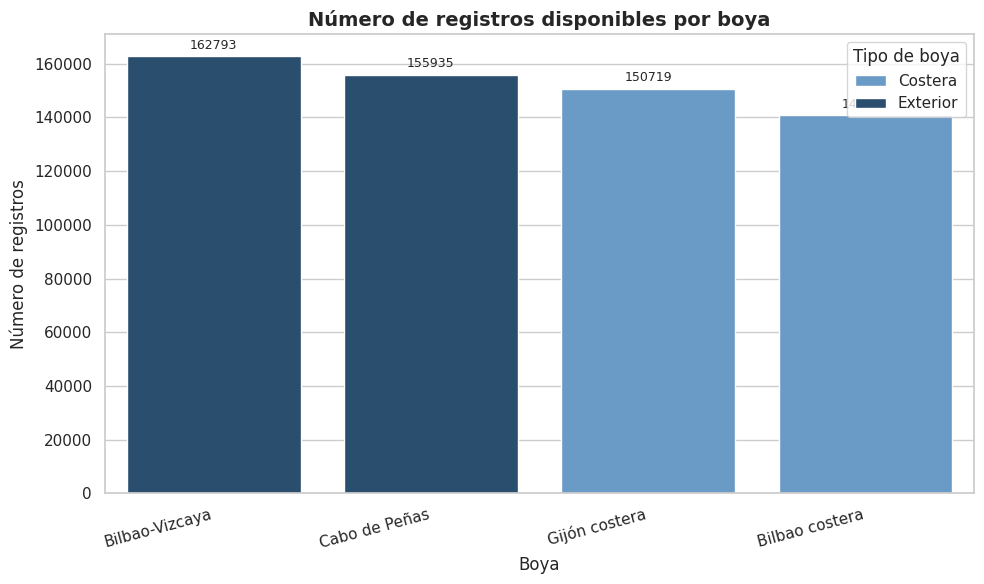

Figura guardada en:
/content/figures/numero_registros_por_boya.png


In [11]:
orden_boyas = (
    resumen_por_boya
    .sort_values("registros", ascending=False)["nombre_boya"]
    .tolist()
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=resumen_por_boya,
    x="nombre_boya",
    y="registros",
    hue="tipo_boya",
    order=orden_boyas,
    palette={
        "Costera": "#5B9BD5",
        "Exterior": "#1F4E79"
    }
)

plt.title(
    "Número de registros disponibles por boya",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Boya")
plt.ylabel("Número de registros")
plt.xticks(rotation=15, ha="right")

# Etiquetas con el número de registros
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3,
        fontsize=9
    )

plt.legend(
    title="Tipo de boya",
    loc="upper right"
)

plt.tight_layout()

ruta_figura_registros = FIGURES_DIR / "numero_registros_por_boya.png"

plt.savefig(
    ruta_figura_registros,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura guardada en:")
print(ruta_figura_registros)

Figura de cobertura temporal

### Cobertura temporal de las series

La cobertura temporal permite comprobar el periodo histórico representado por cada estación. Las cuatro boyas presentan series extensas que abarcan aproximadamente dos décadas, lo que permite realizar análisis de distribución, estacionalidad y episodios de oleaje elevado.

Esta representación muestra el intervalo comprendido entre la primera y la última fecha disponible en cada dataset. No representa todavía los posibles huecos internos de las series, que serán considerados mediante el análisis de disponibilidad y valores válidos.

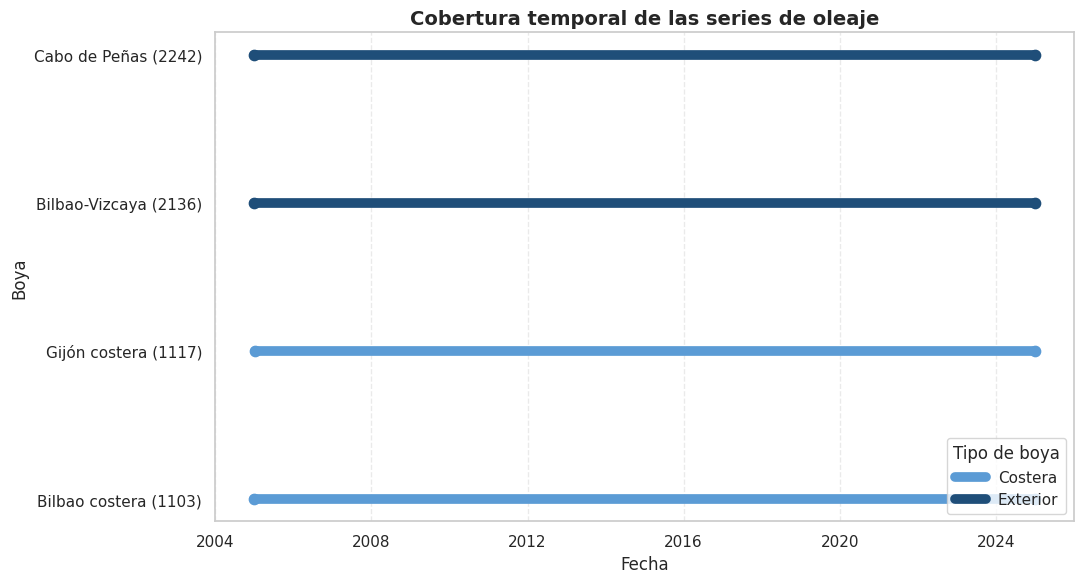

Figura guardada en:
/content/figures/cobertura_temporal_por_boya.png


In [12]:
resumen_cobertura = resumen_por_boya.sort_values(
    ["tipo_boya", "codigo_boya"]
).reset_index(drop=True)

colores_tipo = {
    "Costera": "#5B9BD5",
    "Exterior": "#1F4E79"
}

fig, ax = plt.subplots(figsize=(11, 6))

for posicion, fila in resumen_cobertura.iterrows():
    ax.plot(
        [fila["fecha_inicio"], fila["fecha_fin"]],
        [posicion, posicion],
        linewidth=7,
        color=colores_tipo[fila["tipo_boya"]],
        solid_capstyle="round"
    )

    ax.scatter(
        fila["fecha_inicio"],
        posicion,
        color=colores_tipo[fila["tipo_boya"]],
        s=55,
        zorder=3
    )

    ax.scatter(
        fila["fecha_fin"],
        posicion,
        color=colores_tipo[fila["tipo_boya"]],
        s=55,
        zorder=3
    )

ax.set_yticks(range(len(resumen_cobertura)))

ax.set_yticklabels(
    resumen_cobertura["nombre_boya"] +
    " (" +
    resumen_cobertura["codigo_boya"].astype(str) +
    ")"
)

ax.set_title(
    "Cobertura temporal de las series de oleaje",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Fecha")
ax.set_ylabel("Boya")
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.grid(axis="y", visible=False)

# Leyenda manual
from matplotlib.lines import Line2D

leyenda = [
    Line2D(
        [0], [0],
        color="#5B9BD5",
        linewidth=7,
        label="Costera"
    ),
    Line2D(
        [0], [0],
        color="#1F4E79",
        linewidth=7,
        label="Exterior"
    )
]

ax.legend(
    handles=leyenda,
    title="Tipo de boya",
    loc="lower right"
)

plt.tight_layout()

ruta_figura_cobertura = FIGURES_DIR / "cobertura_temporal_por_boya.png"

plt.savefig(
    ruta_figura_cobertura,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura guardada en:")
print(ruta_figura_cobertura)

Calculo del peso de cada boya en el data set,

In [14]:
# Calcular el porcentaje de registros aportado por cada boya

total_registros = resumen_por_boya["registros"].sum()

resumen_por_boya["porcentaje_dataset"] = (
    resumen_por_boya["registros"] / total_registros * 100
).round(2)

# Mostrar las columnas principales
display(
    resumen_por_boya[
        [
            "codigo_boya",
            "nombre_boya",
            "tipo_boya",
            "registros",
            "porcentaje_dataset"
        ]
    ]
)

# Comprobar la suma de los porcentajes
print(
    "Suma de los porcentajes:",
    resumen_por_boya["porcentaje_dataset"].sum(),
    "%"
)

,codigo_boya,nombre_boya,tipo_boya,registros,porcentaje_dataset
0,1103,Bilbao costera,Costera,140991,23.10
1,1117,Gijón costera,Costera,150719,24.69
2,2136,Bilbao-Vizcaya,Exterior,162793,26.67
3,2242,Cabo de Peñas,Exterior,155935,25.54


Suma de los porcentajes: 100.0 %


In [15]:
resumen_por_boya.to_csv(
    "/content/tables/tabla_resumen_por_boya.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Tabla resumen actualizada correctamente.")
print("Archivo guardado en: /content/tables/tabla_resumen_por_boya.csv")

Tabla resumen actualizada correctamente.
Archivo guardado en: /content/tables/tabla_resumen_por_boya.csv


Interpretación básica resumen por boya

In [16]:
boya_mas_registros = resumen_por_boya.loc[
    resumen_por_boya["registros"].idxmax()
]

boya_menos_registros = resumen_por_boya.loc[
    resumen_por_boya["registros"].idxmin()
]

print("RESUMEN DE COBERTURA")
print("-" * 50)

print(
    f"Boya con más registros: "
    f"{boya_mas_registros['nombre_boya']} "
    f"({boya_mas_registros['registros']:,} registros)"
)

print(
    f"Boya con menos registros: "
    f"{boya_menos_registros['nombre_boya']} "
    f"({boya_menos_registros['registros']:,} registros)"
)

print(
    f"Fecha inicial global: "
    f"{dataset_oleaje['fecha'].min()}"
)

print(
    f"Fecha final global: "
    f"{dataset_oleaje['fecha'].max()}"
)

print(
    f"Total de registros: "
    f"{len(dataset_oleaje):,}"
)

RESUMEN DE COBERTURA
--------------------------------------------------
Boya con más registros: Bilbao-Vizcaya (162,793 registros)
Boya con menos registros: Bilbao costera (140,991 registros)
Fecha inicial global: 2004-12-31 00:00:00
Fecha final global: 2024-12-31 23:00:00
Total de registros: 610,438


### Interpretación de la cobertura temporal

El dataset principal de oleaje contiene más de 610.000 registros procedentes de cuatro boyas costeras y exteriores. Las series abarcan aproximadamente veinte años, desde finales de 2004 o principios de 2005 hasta diciembre de 2024.

El número de registros no es exactamente igual en todas las boyas, debido a diferencias en la fecha inicial y a posibles discontinuidades internas en las series. No obstante, las cuatro estaciones presentan un volumen elevado de observaciones y una representación relativamente equilibrada dentro del dataset conjunto.

Esta cobertura temporal proporciona una base adecuada para estudiar el comportamiento general del oleaje, su distribución estadística y la presencia de valores extremos. También permitirá desarrollar posteriormente indicadores mensuales, estacionales y de episodios potencialmente adversos.

Las boyas costeras y exteriores no se consideran mediciones equivalentes de una misma condición. Las boyas exteriores representan situaciones más expuestas a mar abierto, mientras que las boyas costeras ofrecen información más próxima al entorno litoral y portuario. Por tanto, las diferencias se analizarán como información complementaria para la gestión portuaria y no como una comparación competitiva entre puertos.

# INTRODUCCIÓN, ESTADÍSTICOS DESCRIPTIVOS

## 2. Estadísticos descriptivos de las variables de oleaje

En esta sección se calculan los principales estadísticos descriptivos de las variables de oleaje para cada boya.

Las variables analizadas son:

- `Hs_m`: altura significativa del oleaje, expresada en metros.
- `Hmax_m`: altura máxima del oleaje, expresada en metros.
- `Tm02_s`: periodo medio Tm02, expresado en segundos.
- `Tp_s`: periodo de pico, expresado en segundos.

Para facilitar la interpretación de la distribución de Hs se calculan:

- número de observaciones válidas;
- media;
- mediana;
- desviación típica;
- mínimo;
- percentiles 25, 75, 90, 95 y 99;
- máximo.

Los percentiles altos permiten caracterizar condiciones de oleaje elevado sin depender únicamente de los máximos absolutos, que pueden corresponder a episodios muy puntuales.

Las diferencias observadas entre estaciones se interpretan considerando el tipo de boya y su exposición marítima. El objetivo no es realizar una clasificación competitiva entre puertos, sino obtener indicadores objetivos que puedan apoyar la gestión portuaria.

 Se comprueban las variables disponibles

In [17]:
variables_oleaje = ["Hs_m", "Hmax_m", "Tm02_s", "Tp_s"]

for variable in variables_oleaje:
    print(variable, variable in dataset_oleaje.columns)

Hs_m True
Hmax_m True
Tm02_s True
Tp_s True


Se calculan los estadísticos descriptivos de Hs por boya

In [18]:
estadisticos_hs = (
    dataset_oleaje
    .groupby(
        [
            "codigo_boya",
            "nombre_boya",
            "tipo_boya"
        ]
    )["Hs_m"]
    .agg(
        observaciones_validas="count",
        media="mean",
        mediana="median",
        desviacion_tipica="std",
        minimo="min",
        percentil_25=lambda x: x.quantile(0.25),
        percentil_75=lambda x: x.quantile(0.75),
        percentil_90=lambda x: x.quantile(0.90),
        percentil_95=lambda x: x.quantile(0.95),
        percentil_99=lambda x: x.quantile(0.99),
        maximo="max"
    )
    .reset_index()
)

columnas_numericas = [
    "media",
    "mediana",
    "desviacion_tipica",
    "minimo",
    "percentil_25",
    "percentil_75",
    "percentil_90",
    "percentil_95",
    "percentil_99",
    "maximo"
]

estadisticos_hs[columnas_numericas] = (
    estadisticos_hs[columnas_numericas]
    .round(2)
)

display(estadisticos_hs)

,codigo_boya,nombre_boya,tipo_boya,observaciones_validas,media,mediana,desviacion_tipica,minimo,percentil_25,percentil_75,percentil_90,percentil_95,percentil_99,maximo
0,1103,Bilbao costera,Costera,140988,1.43,1.20,0.84,0.00,0.83,1.80,2.57,3.11,4.35,8.37
1,1117,Gijón costera,Costera,150719,1.63,1.42,0.88,0.01,1.01,2.03,2.79,3.34,4.62,8.98
2,2136,Bilbao-Vizcaya,Exterior,162789,1.94,1.59,1.24,0.01,1.08,2.44,3.62,4.44,6.34,13.72
3,2242,Cabo de Peñas,Exterior,155935,2.03,1.72,1.17,0.01,1.21,2.53,3.60,4.31,6.10,12.18


Guardar tanbla, Estadísticos de Hs

In [19]:
ruta_estadisticos_hs = (
    TABLES_DIR / "tabla_estadisticos_hs_por_boya.csv"
)

estadisticos_hs.to_csv(
    ruta_estadisticos_hs,
    index=False,
    encoding="utf-8-sig"
)

print("Tabla guardada correctamente:")
print(ruta_estadisticos_hs)

Tabla guardada correctamente:
/content/tables/tabla_estadisticos_hs_por_boya.csv


Estadísticos de las variables principales por boya

In [20]:
tabla_estadisticos_oleaje = (
    dataset_oleaje
    .groupby(
        [
            "codigo_boya",
            "nombre_boya",
            "tipo_boya"
        ],
        as_index=False
    )
    .agg(
        registros=("fecha", "size"),
        Hs_media_m=("Hs_m", "mean"),
        Hs_mediana_m=("Hs_m", "median"),
        Hs_p90_m=("Hs_m", lambda x: x.quantile(0.90)),
        Hs_p95_m=("Hs_m", lambda x: x.quantile(0.95)),
        Hs_p99_m=("Hs_m", lambda x: x.quantile(0.99)),
        Hs_maxima_m=("Hs_m", "max"),
        Hmax_media_m=("Hmax_m", "mean"),
        Hmax_maxima_m=("Hmax_m", "max"),
        Tm02_media_s=("Tm02_s", "mean"),
        Tp_media_s=("Tp_s", "mean"),
        Tp_maximo_s=("Tp_s", "max")
    )
)

columnas_redondear = [
    "Hs_media_m",
    "Hs_mediana_m",
    "Hs_p90_m",
    "Hs_p95_m",
    "Hs_p99_m",
    "Hs_maxima_m",
    "Hmax_media_m",
    "Hmax_maxima_m",
    "Tm02_media_s",
    "Tp_media_s",
    "Tp_maximo_s"
]

tabla_estadisticos_oleaje[columnas_redondear] = (
    tabla_estadisticos_oleaje[columnas_redondear]
    .round(2)
)

tabla_estadisticos_oleaje = (
    tabla_estadisticos_oleaje
    .sort_values("codigo_boya")
    .reset_index(drop=True)
)

display(tabla_estadisticos_oleaje)

,codigo_boya,nombre_boya,tipo_boya,registros,Hs_media_m,Hs_mediana_m,Hs_p90_m,Hs_p95_m,Hs_p99_m,Hs_maxima_m,Hmax_media_m,Hmax_maxima_m,Tm02_media_s,Tp_media_s,Tp_maximo_s
0,1103,Bilbao costera,Costera,140991,1.43,1.20,2.57,3.11,4.35,8.37,2.16,13.72,5.48,9.05,28.60
1,1117,Gijón costera,Costera,150719,1.63,1.42,2.79,3.34,4.62,8.98,2.46,13.99,5.86,9.17,25.00
2,2136,Bilbao-Vizcaya,Exterior,162793,1.94,1.59,3.62,4.44,6.34,13.72,2.91,22.63,6.06,9.63,22.27
3,2242,Cabo de Peñas,Exterior,155935,2.03,1.72,3.60,4.31,6.10,12.18,3.10,23.28,6.09,9.48,19.92


Guardar la tabla

In [22]:
ruta_tabla_estadisticos = (
    TABLES_DIR / "tabla_estadisticos_oleaje.csv"
)

tabla_estadisticos_oleaje.to_csv(
    ruta_tabla_estadisticos,
    index=False,
    encoding="utf-8-sig"
)

print("Tabla guardada correctamente:")
print(ruta_tabla_estadisticos)

Tabla guardada correctamente:
/content/tables/tabla_estadisticos_oleaje.csv


RESUMEN

### Resumen según el tipo de boya

Las boyas costeras y exteriores se encuentran en contextos de exposición diferentes. Por ello, se calcula un resumen agrupado por tipo de boya.

Este análisis permite valorar de forma general cómo cambia la distribución de Hs entre estaciones costeras y estaciones exteriores. El resultado no debe interpretarse como una comparación entre puertos, sino como una comprobación de que la localización y exposición de la boya influyen en los valores registrados.

In [23]:
tabla_resumen_tipo_boya = (
    dataset_oleaje
    .groupby(
        "tipo_boya",
        as_index=False
    )
    .agg(
        registros=("fecha", "size"),
        boyas_incluidas=("codigo_boya", "nunique"),
        Hs_media_m=("Hs_m", "mean"),
        Hs_mediana_m=("Hs_m", "median"),
        Hs_desviacion_m=("Hs_m", "std"),
        Hs_p90_m=("Hs_m", lambda x: x.quantile(0.90)),
        Hs_p95_m=("Hs_m", lambda x: x.quantile(0.95)),
        Hs_p99_m=("Hs_m", lambda x: x.quantile(0.99)),
        Hs_maxima_m=("Hs_m", "max"),
        Hmax_media_m=("Hmax_m", "mean"),
        Tm02_media_s=("Tm02_s", "mean"),
        Tp_media_s=("Tp_s", "mean")
    )
)

columnas_tipo_boya = [
    "Hs_media_m",
    "Hs_mediana_m",
    "Hs_desviacion_m",
    "Hs_p90_m",
    "Hs_p95_m",
    "Hs_p99_m",
    "Hs_maxima_m",
    "Hmax_media_m",
    "Tm02_media_s",
    "Tp_media_s"
]

tabla_resumen_tipo_boya[columnas_tipo_boya] = (
    tabla_resumen_tipo_boya[columnas_tipo_boya]
    .round(2)
)

display(tabla_resumen_tipo_boya)

,tipo_boya,registros,boyas_incluidas,Hs_media_m,Hs_mediana_m,Hs_desviacion_m,Hs_p90_m,Hs_p95_m,Hs_p99_m,Hs_maxima_m,Hmax_media_m,Tm02_media_s,Tp_media_s
0,Costera,291710,2,1.53,1.32,0.87,2.69,3.24,4.48,8.98,2.31,5.67,9.11
1,Exterior,318728,2,1.99,1.66,1.21,3.61,4.37,6.23,13.72,3.01,6.07,9.56


In [25]:
ruta_resumen_tipo_boya = (
    TABLES_DIR / "tabla_resumen_tipo_boya.csv"
)

tabla_resumen_tipo_boya.to_csv(
    ruta_resumen_tipo_boya,
    index=False,
    encoding="utf-8-sig"
)

print("Tabla guardada correctamente:")
print(ruta_resumen_tipo_boya)

Tabla guardada correctamente:
/content/tables/tabla_resumen_tipo_boya.csv


Resumen archivos creados, comprobación

In [26]:
print("Tablas disponibles en /content/tables:")

for archivo in sorted(os.listdir(TABLES_DIR)):
    print("-", archivo)

Tablas disponibles en /content/tables:
- tabla_estadisticos_hs_por_boya.csv
- tabla_estadisticos_oleaje.csv
- tabla_resumen_por_boya.csv
- tabla_resumen_tipo_boya.csv


### Interpretación inicial de los estadísticos descriptivos

Los resultados muestran que las boyas exteriores presentan, en términos generales, valores medios, medianas y percentiles altos de Hs superiores a los registrados por las boyas costeras. Este resultado es coherente con su mayor exposición a condiciones de mar abierto.

La media permite describir el comportamiento general del oleaje, mientras que la mediana representa mejor el valor central cuando la distribución contiene episodios elevados. Los percentiles 90, 95 y 99 aportan información especialmente útil para la gestión portuaria, ya que permiten identificar niveles de oleaje poco frecuentes sin depender exclusivamente del máximo absoluto.

Los máximos registrados deben interpretarse con cautela, ya que representan observaciones puntuales y pueden estar asociados a episodios extremos. Por este motivo, los percentiles altos serán utilizados como indicadores más estables para caracterizar condiciones de oleaje elevado.

Las diferencias observadas entre las estaciones costeras y exteriores no representan una valoración entre puertos. Reflejan principalmente diferencias en la localización de los sensores y en el grado de exposición marítima. Desde la perspectiva de la gestión portuaria, ambas fuentes de información son complementarias: las boyas exteriores permiten observar la señal de mar abierto, mientras que las costeras permiten aproximarse mejor a las condiciones del entorno litoral.

# GRÁFICOS ANÁLISIS EXPLORATORIO

## 3. Análisis gráfico de la distribución de Hs

### Boxplot de Hs por boya

El boxplot permite representar la distribución de la altura significativa del oleaje, Hs, en cada boya.

La línea central de cada caja representa la mediana. Los límites inferior y superior de la caja corresponden a los percentiles 25 y 75. La amplitud de la caja muestra la variabilidad central de los datos.

En esta primera representación se ocultan los valores atípicos individuales para evitar que la elevada cantidad de registros dificulte la lectura del gráfico. Estos valores no se eliminan del dataset y serán considerados posteriormente en el análisis de episodios de oleaje elevado.

Las diferencias entre boyas deben interpretarse teniendo en cuenta la localización y exposición marítima de cada estación. El gráfico no pretende establecer una clasificación entre puertos.

In [27]:
orden_boyas = [
    "Bilbao costera",
    "Gijón costera",
    "Bilbao-Vizcaya",
    "Cabo de Peñas"
]

print("Orden utilizado en los gráficos:")

for boya in orden_boyas:
    print("-", boya)

Orden utilizado en los gráficos:
- Bilbao costera
- Gijón costera
- Bilbao-Vizcaya
- Cabo de Peñas


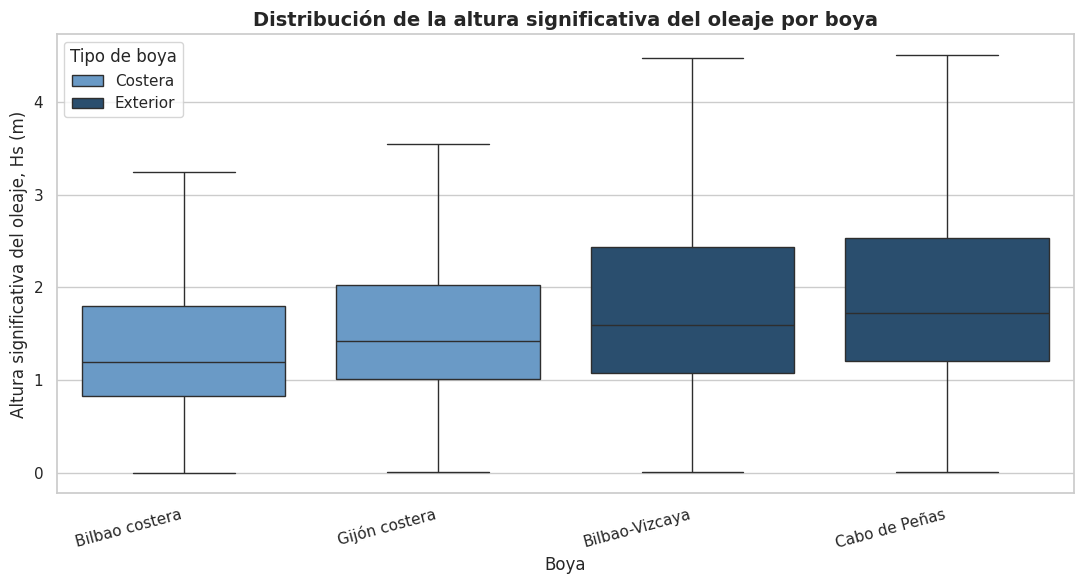

Figura guardada correctamente:
/content/figures/boxplot_hs_por_boya.png


In [28]:
plt.figure(figsize=(11, 6))

ax = sns.boxplot(
    data=dataset_oleaje,
    x="nombre_boya",
    y="Hs_m",
    hue="tipo_boya",
    order=orden_boyas,
    palette={
        "Costera": "#5B9BD5",
        "Exterior": "#1F4E79"
    },
    showfliers=False
)

plt.title(
    "Distribución de la altura significativa del oleaje por boya",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Boya")
plt.ylabel("Altura significativa del oleaje, Hs (m)")
plt.xticks(rotation=15, ha="right")

plt.legend(
    title="Tipo de boya",
    loc="upper left"
)

plt.tight_layout()

ruta_boxplot_hs = FIGURES_DIR / "boxplot_hs_por_boya.png"

plt.savefig(
    ruta_boxplot_hs,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura guardada correctamente:")
print(ruta_boxplot_hs)

Se añaden las medianas al análisis

In [31]:
medianas_hs = (
    dataset_oleaje
    .groupby(
        [
            "codigo_boya",
            "nombre_boya",
            "tipo_boya"
        ],
        as_index=False
    )
    .agg(
        Hs_mediana_m=("Hs_m", "median"),
        Hs_percentil_25_m=("Hs_m", lambda x: x.quantile(0.25)),
        Hs_percentil_75_m=("Hs_m", lambda x: x.quantile(0.75))
    )
)

columnas_mediana = [
    "Hs_mediana_m",
    "Hs_percentil_25_m",
    "Hs_percentil_75_m"
]

medianas_hs[columnas_mediana] = (
    medianas_hs[columnas_mediana].round(2)
)

display(medianas_hs)

,codigo_boya,nombre_boya,tipo_boya,Hs_mediana_m,Hs_percentil_25_m,Hs_percentil_75_m
0,1103,Bilbao costera,Costera,1.20,0.83,1.80
1,1117,Gijón costera,Costera,1.42,1.01,2.03
2,2136,Bilbao-Vizcaya,Exterior,1.59,1.08,2.44
3,2242,Cabo de Peñas,Exterior,1.72,1.21,2.53


### Histogramas de Hs por boya

Los histogramas permiten analizar la frecuencia con la que aparecen los diferentes valores de Hs en cada estación.

Para facilitar la comparación visual, las cuatro boyas se representan en paneles independientes con la misma escala horizontal. La línea vertical discontinua indica la media de Hs de cada boya.

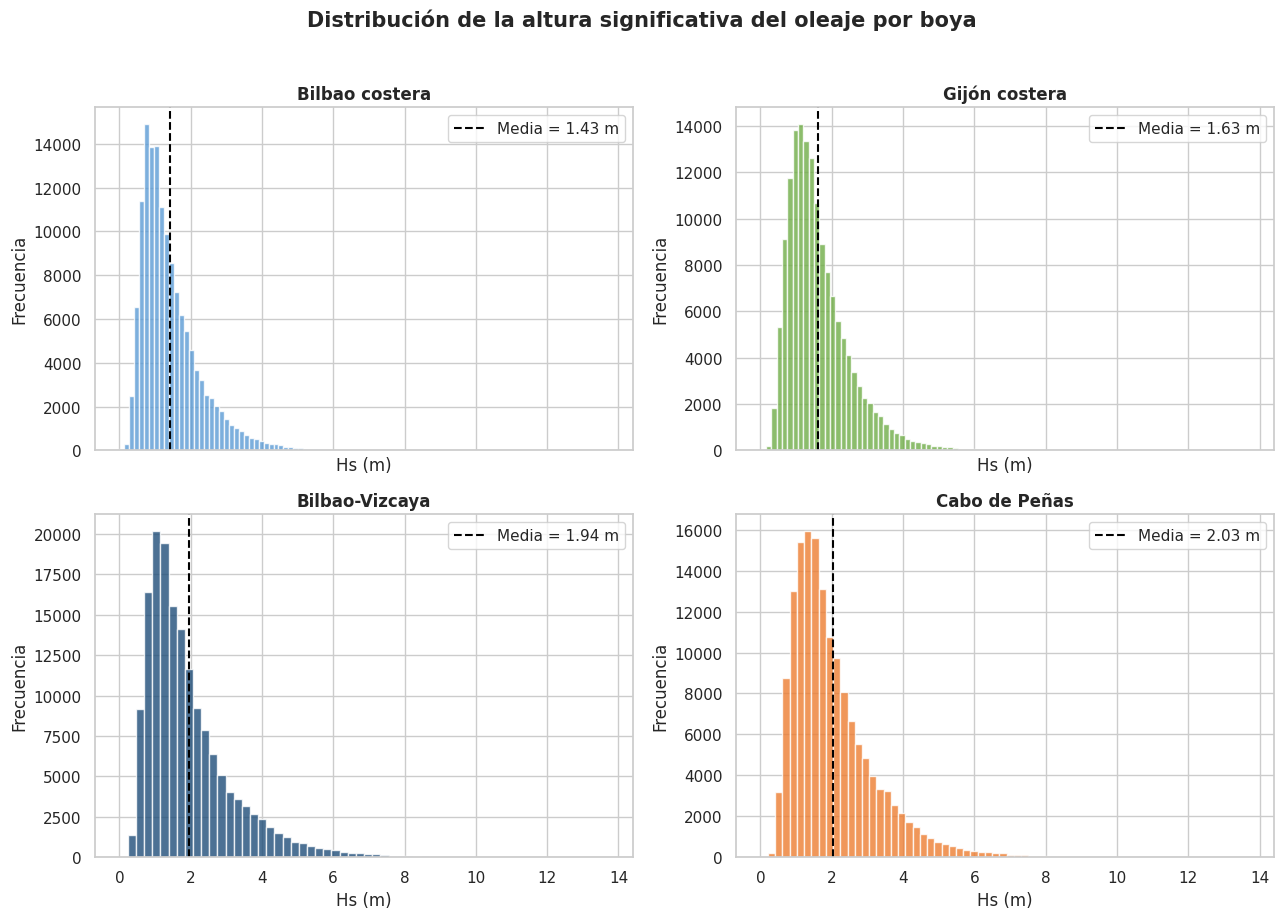

Figura guardada correctamente:
/content/figures/histogramas_hs_por_boya.png


In [32]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 9),
    sharex=True
)

axes = axes.flatten()

colores_boya = {
    "Bilbao costera": "#5B9BD5",
    "Gijón costera": "#70AD47",
    "Bilbao-Vizcaya": "#1F4E79",
    "Cabo de Peñas": "#ED7D31"
}

for ax, nombre_boya in zip(axes, orden_boyas):

    datos_boya = dataset_oleaje.loc[
        dataset_oleaje["nombre_boya"] == nombre_boya,
        "Hs_m"
    ].dropna()

    media_hs = datos_boya.mean()

    ax.hist(
        datos_boya,
        bins=60,
        color=colores_boya[nombre_boya],
        alpha=0.80,
        edgecolor="white"
    )

    ax.axvline(
        media_hs,
        color="black",
        linestyle="--",
        linewidth=1.5,
        label=f"Media = {media_hs:.2f} m"
    )

    ax.set_title(
        nombre_boya,
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xlabel("Hs (m)")
    ax.set_ylabel("Frecuencia")
    ax.legend()

fig.suptitle(
    "Distribución de la altura significativa del oleaje por boya",
    fontsize=15,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

ruta_histogramas = FIGURES_DIR / "histogramas_hs_por_boya.png"

plt.savefig(
    ruta_histogramas,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura guardada correctamente:")
print(ruta_histogramas)

### Interpretación de los histogramas

Los histogramas muestran distribuciones asimétricas hacia la derecha. La mayor parte de las observaciones se concentra en valores bajos y moderados de Hs, mientras que las alturas elevadas presentan una frecuencia progresivamente menor.

La existencia de una cola derecha prolongada confirma que la media puede estar condicionada por episodios de oleaje elevado. Por esta razón, la interpretación conjunta de la media, la mediana y los percentiles resulta más adecuada que el uso de un único estadístico.

Las distribuciones de las boyas exteriores aparecen desplazadas hacia valores de Hs mayores, en coherencia con su exposición a mar abierto. Las boyas costeras presentan una mayor concentración en valores inferiores, aunque mantienen colas asociadas a episodios de mayor intensidad.

Este comportamiento justifica la utilización posterior de percentiles y umbrales para convertir las series históricas en indicadores interpretables desde la gestión portuaria.

In [33]:
print("FIGURAS GENERADAS")
print("-" * 50)

for archivo in sorted(os.listdir(FIGURES_DIR)):
    print("-", archivo)

FIGURAS GENERADAS
--------------------------------------------------
- boxplot_hs_por_boya.png
- cobertura_temporal_por_boya.png
- histogramas_hs_por_boya.png
- numero_registros_por_boya.png


In [34]:
for archivo in sorted(os.listdir(FIGURES_DIR)):
    ruta = FIGURES_DIR / archivo
    tamano_kb = ruta.stat().st_size / 1024

    print(
        archivo,
        "-",
        round(tamano_kb, 2),
        "KB"
    )

boxplot_hs_por_boya.png - 174.91 KB
cobertura_temporal_por_boya.png - 144.85 KB
histogramas_hs_por_boya.png - 315.28 KB
numero_registros_por_boya.png - 206.15 KB



Figura: boxplot_hs_por_boya.png


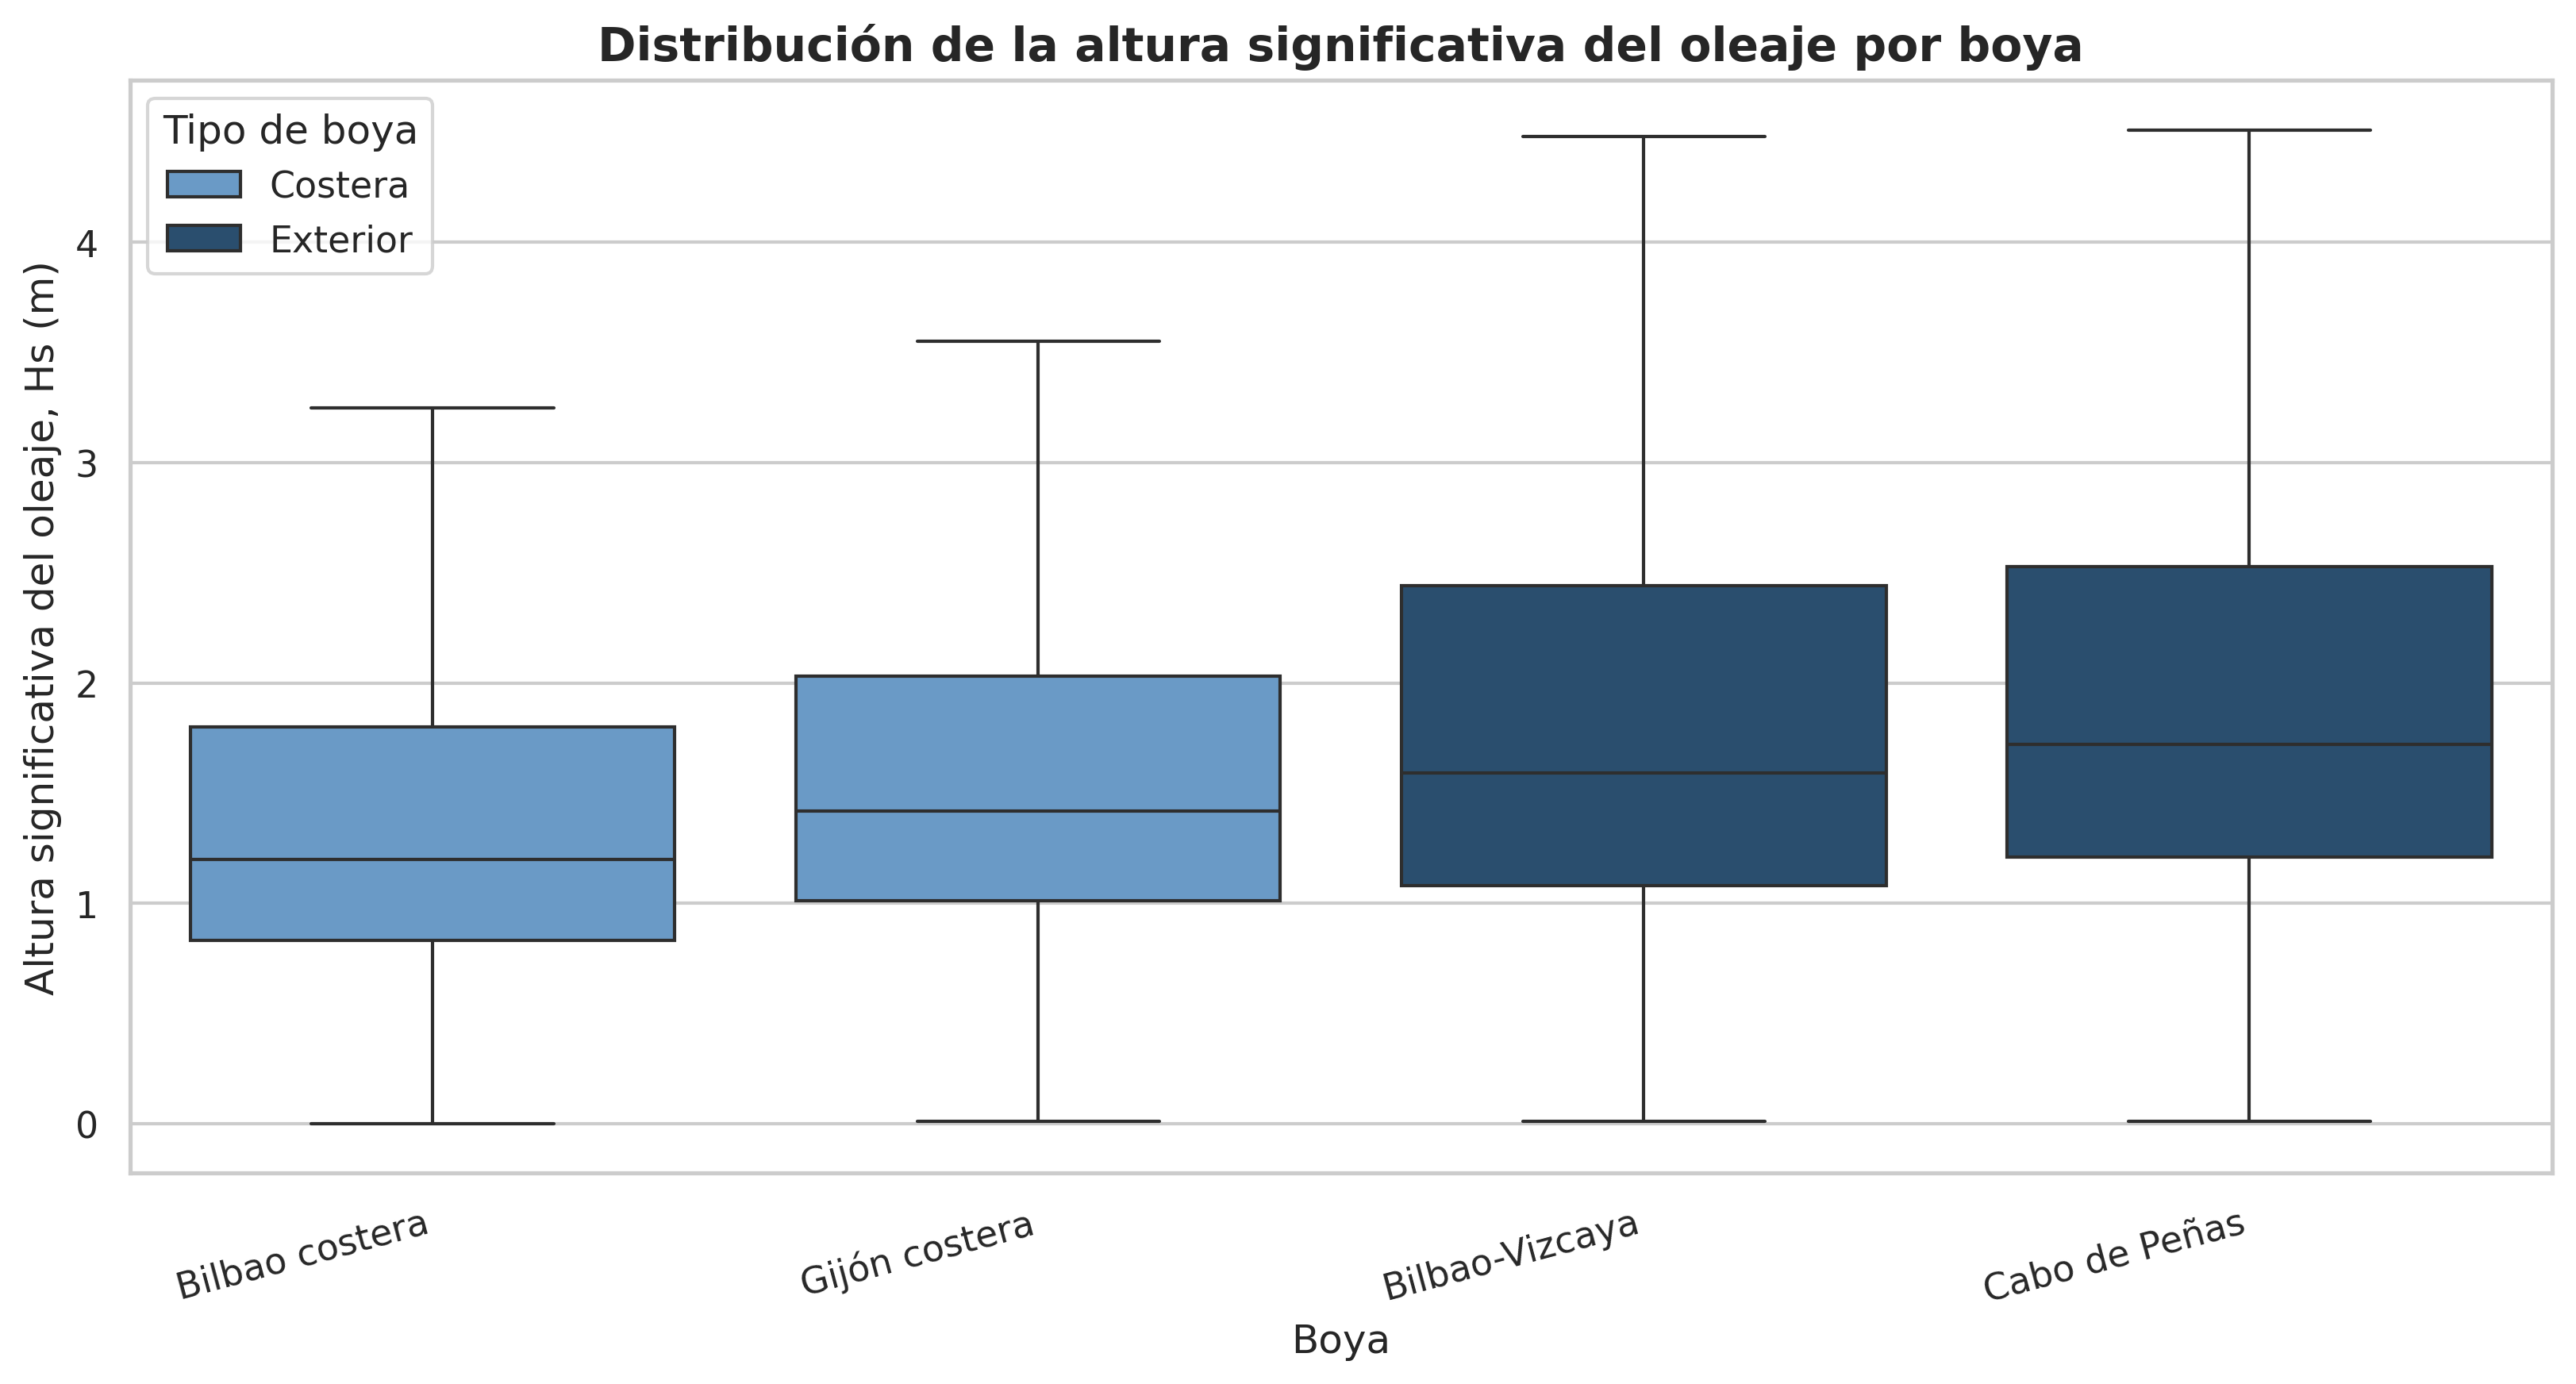


Figura: cobertura_temporal_por_boya.png


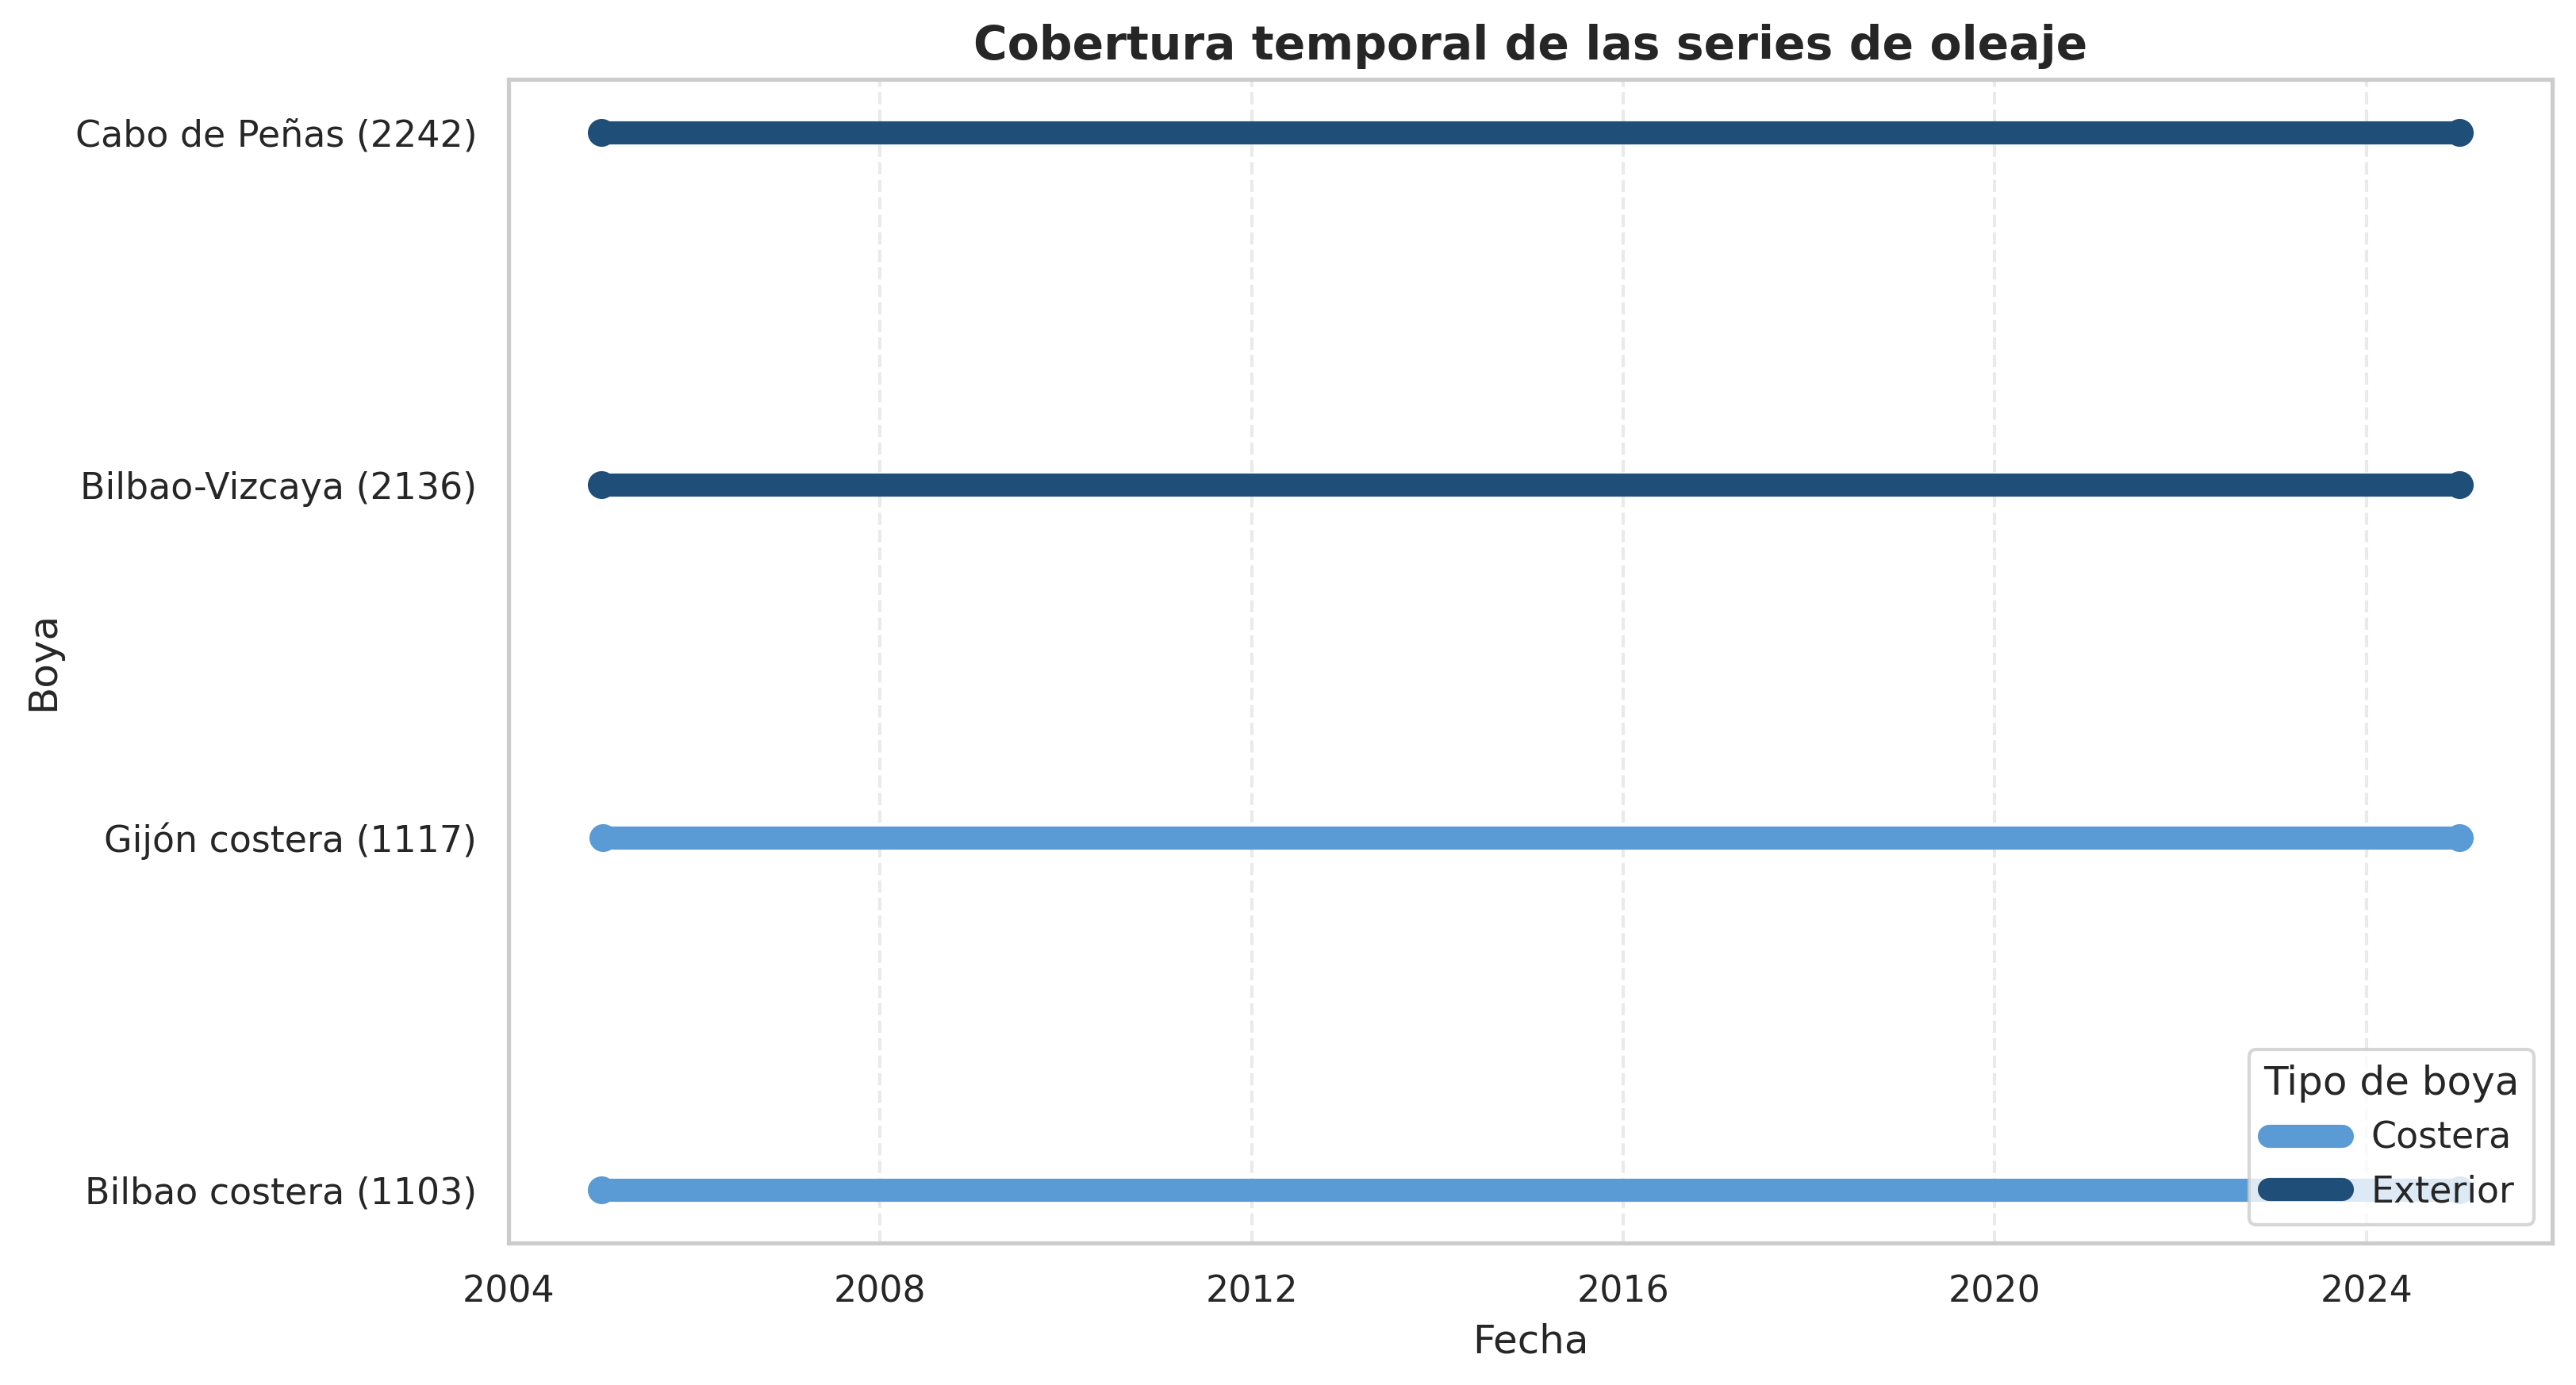


Figura: histogramas_hs_por_boya.png


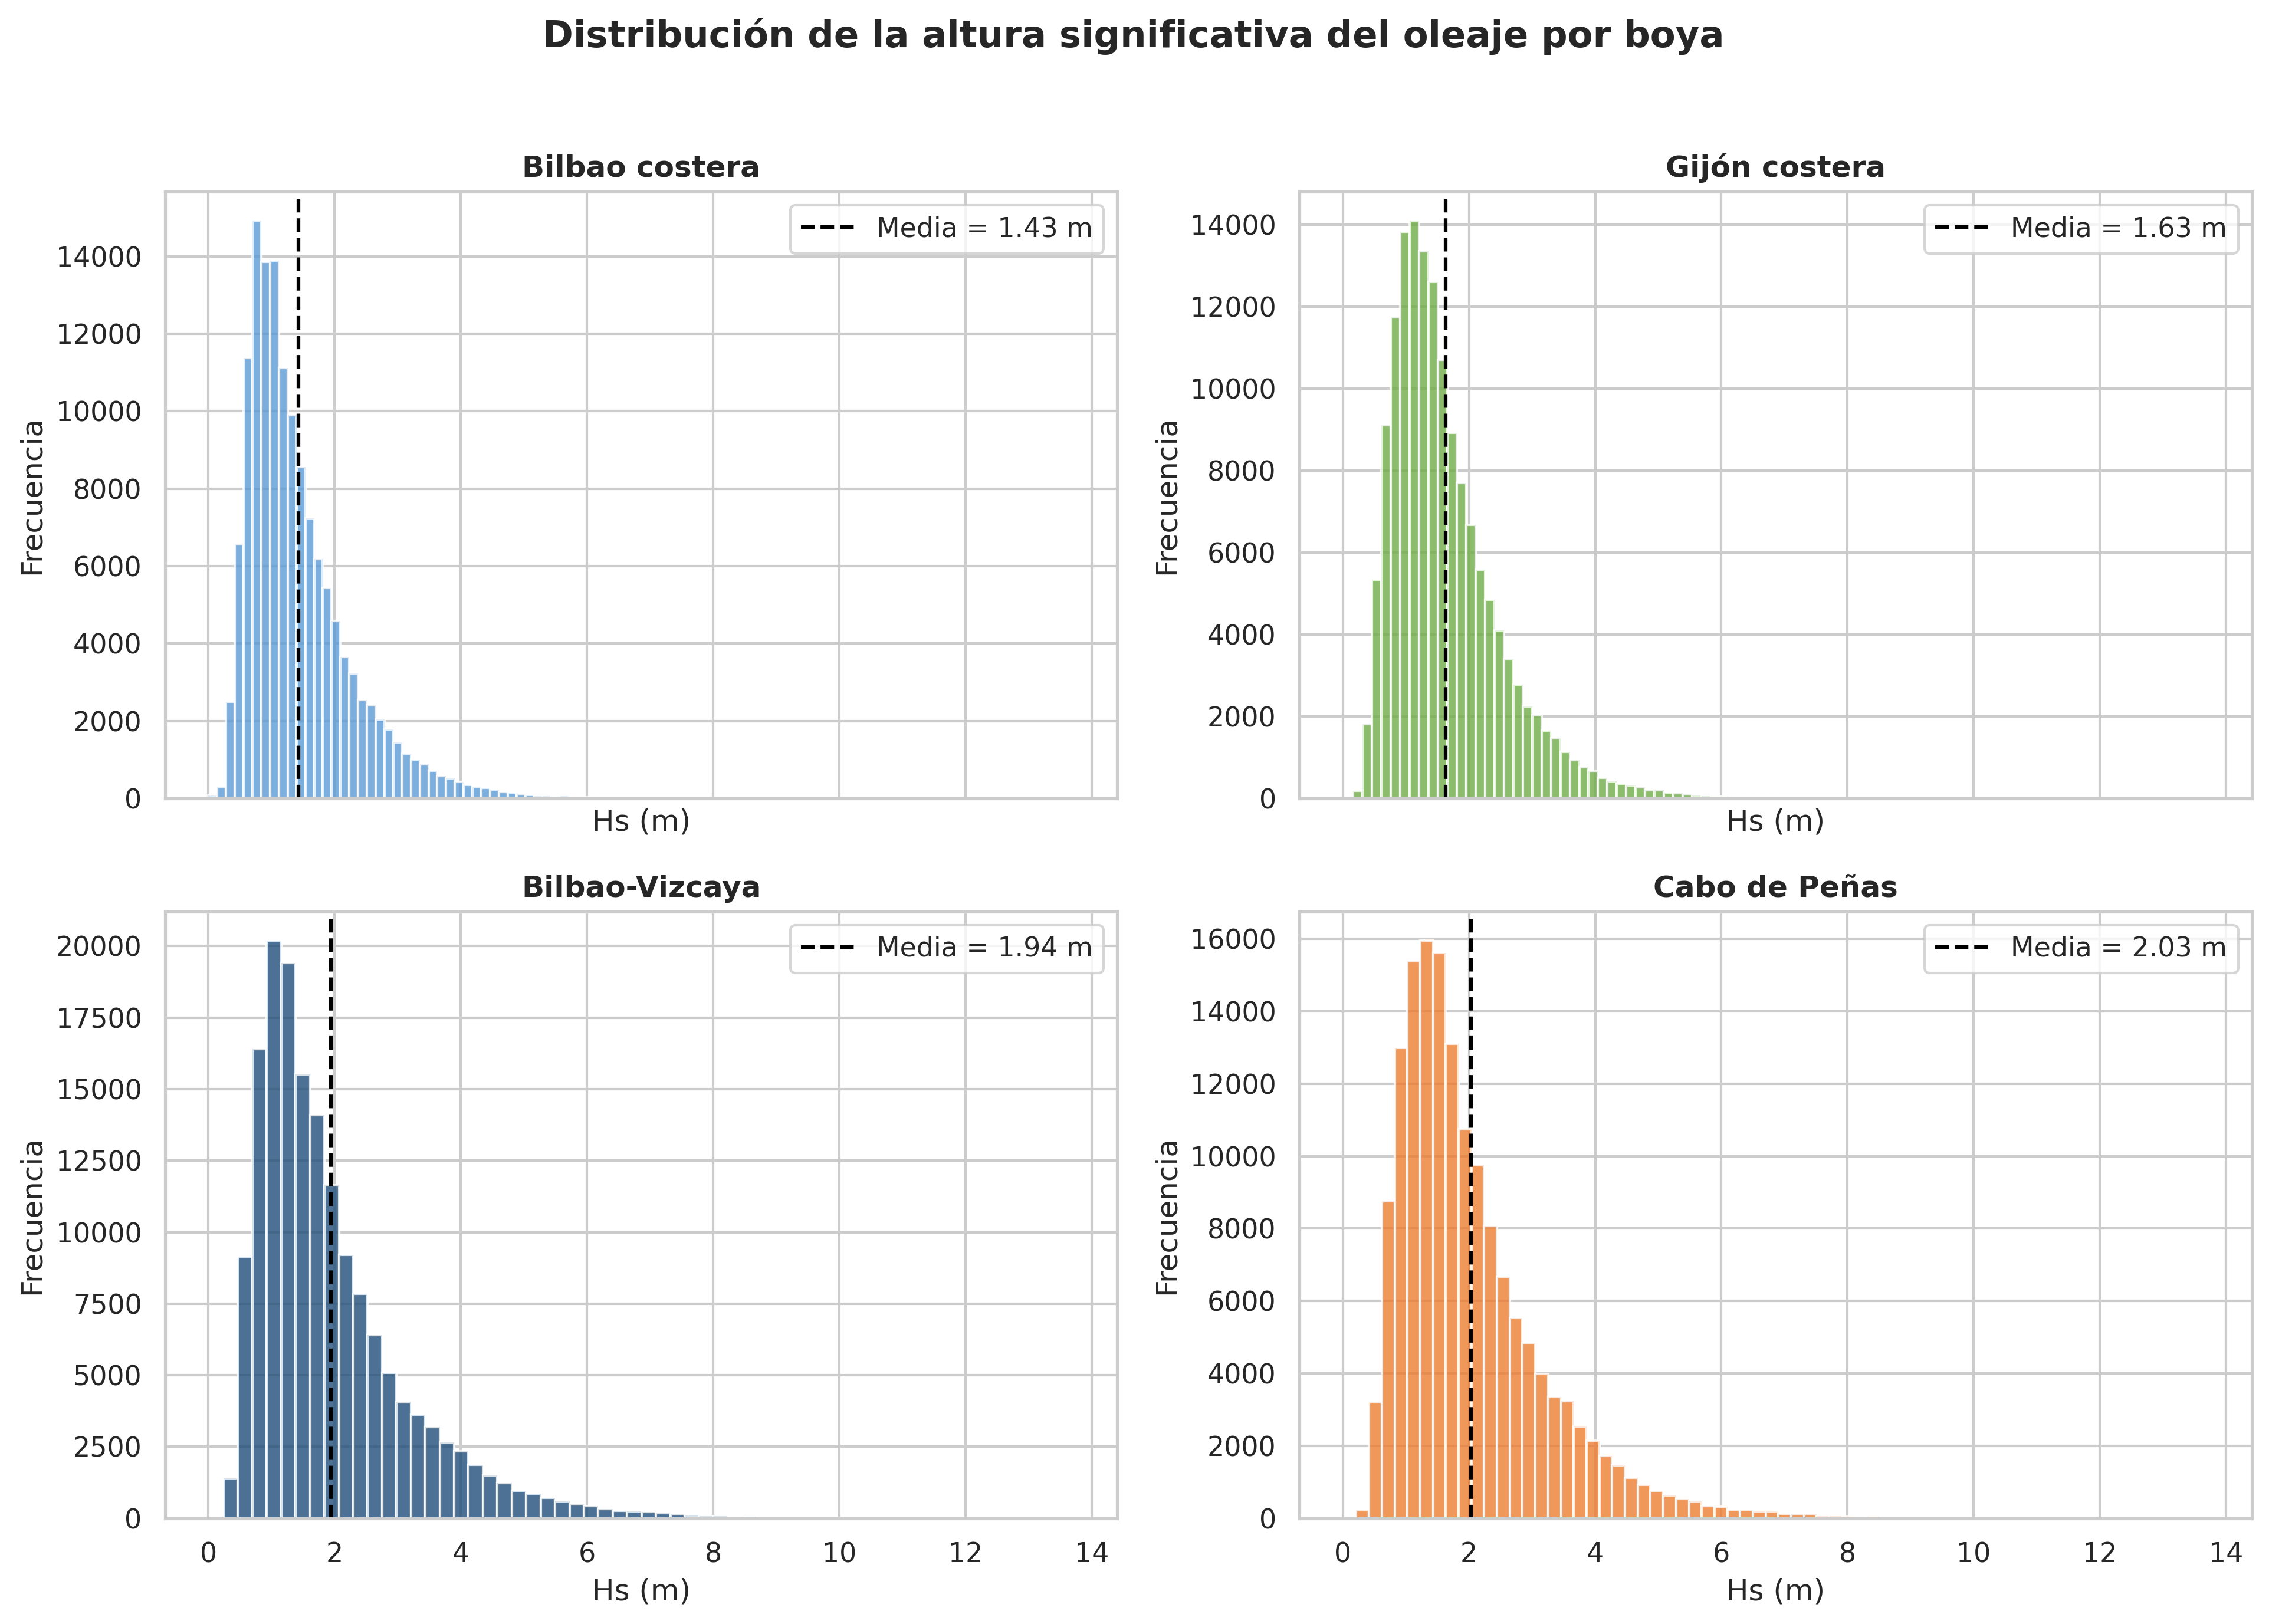


Figura: numero_registros_por_boya.png


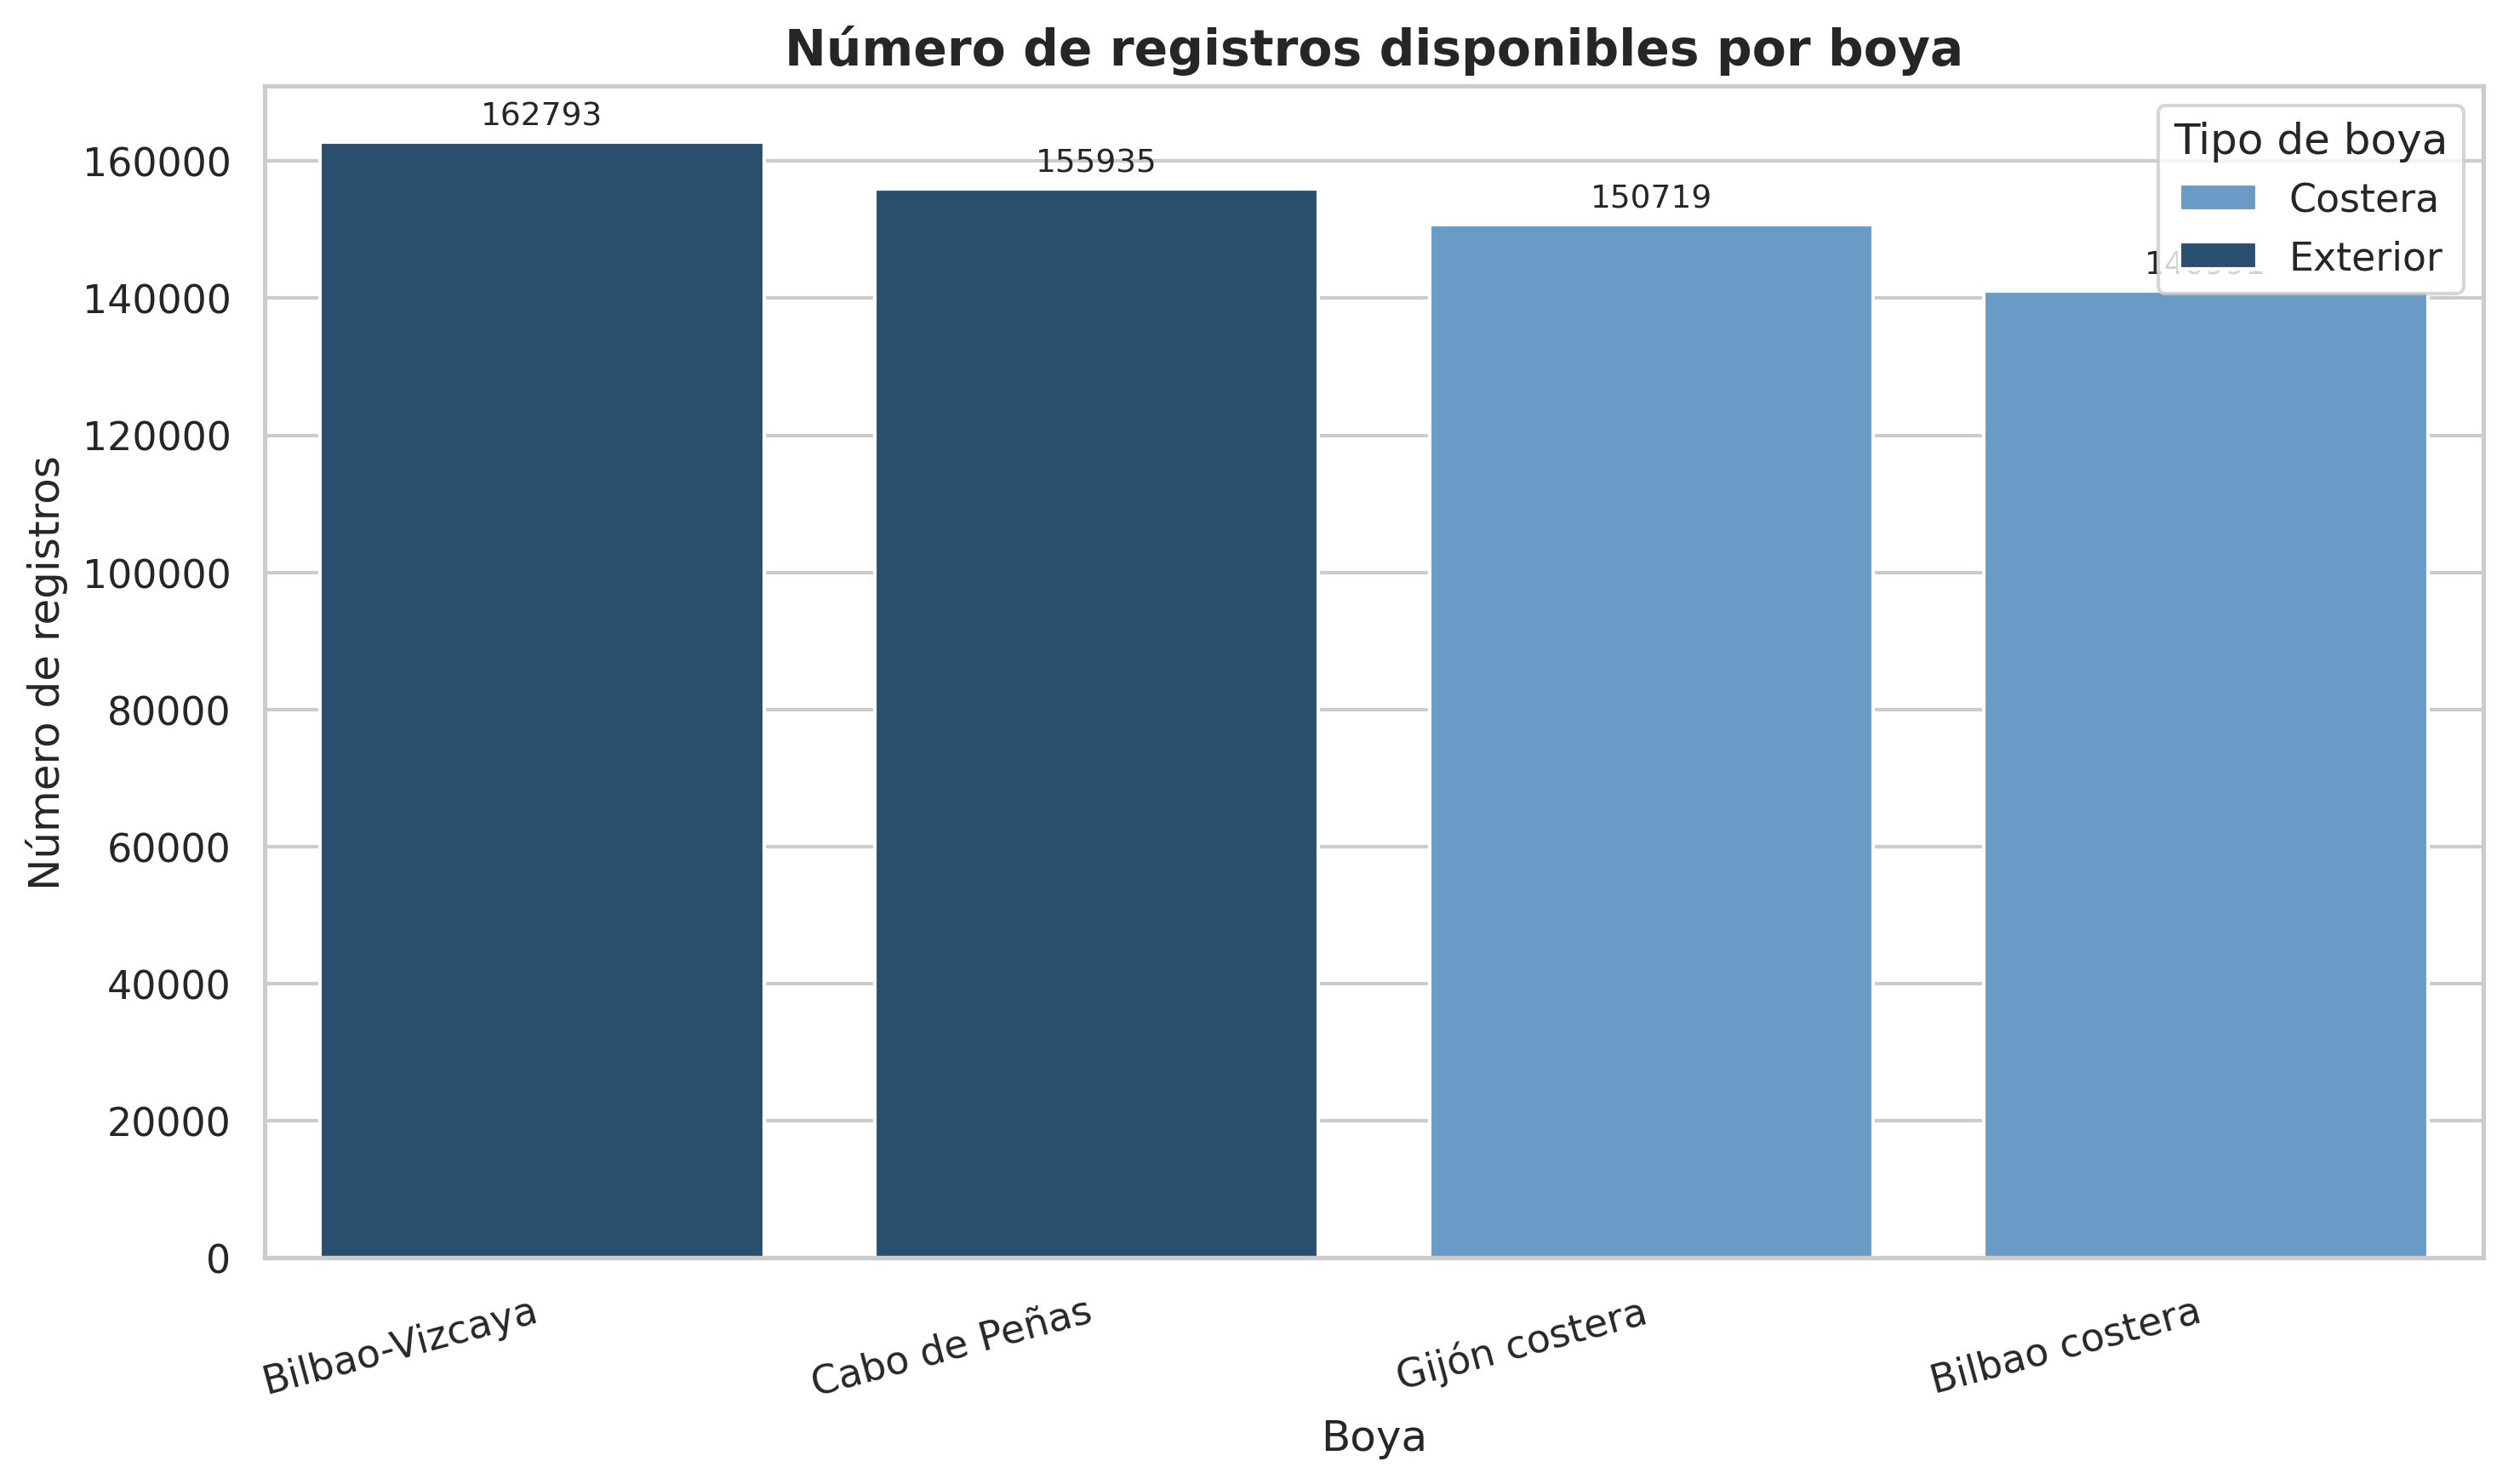

In [35]:
from IPython.display import Image, display

for archivo in sorted(os.listdir(FIGURES_DIR)):
    print("\nFigura:", archivo)

    display(
        Image(
            filename=str(FIGURES_DIR / archivo),
            width=850
        )
    )

### Distribución de Hs según el tipo de boya

Las observaciones se agrupan en dos categorías: boyas costeras y boyas exteriores. El objetivo es analizar cómo varía la distribución general de la altura significativa de ola, Hs, según el grado de exposición de la estación.

Este análisis no constituye una comparación entre puertos. Las boyas exteriores representan condiciones de mar abierto, mientras que las boyas costeras aportan información más próxima al entorno litoral y portuario.

Para facilitar la interpretación visual, no se representan individualmente los valores atípicos en el boxplot. Estos registros no se eliminan del dataset y serán estudiados posteriormente en el análisis de episodios potencialmente adversos.

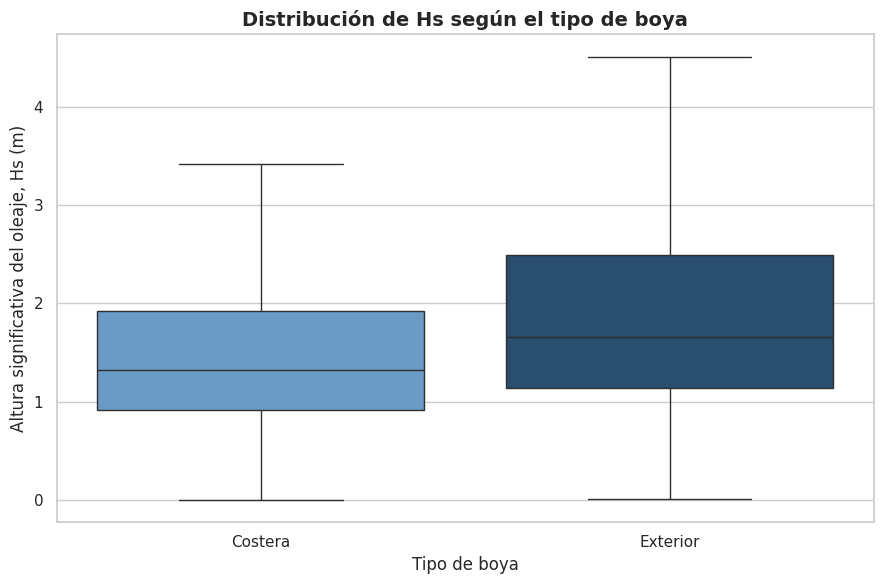

Figura guardada correctamente:
/content/figures/distribucion_hs_por_tipo_boya.png


In [36]:
plt.figure(figsize=(9, 6))

ax = sns.boxplot(
    data=dataset_oleaje,
    x="tipo_boya",
    y="Hs_m",
    order=["Costera", "Exterior"],
    hue="tipo_boya",
    palette={
        "Costera": "#5B9BD5",
        "Exterior": "#1F4E79"
    },
    showfliers=False,
    legend=False
)

plt.title(
    "Distribución de Hs según el tipo de boya",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Tipo de boya")
plt.ylabel("Altura significativa del oleaje, Hs (m)")

plt.tight_layout()

ruta_boxplot_tipo = (
    FIGURES_DIR / "distribucion_hs_por_tipo_boya.png"
)

plt.savefig(
    ruta_boxplot_tipo,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura guardada correctamente:")
print(ruta_boxplot_tipo)

In [37]:
resumen_distribucion_tipo = (
    dataset_oleaje
    .groupby(
        "tipo_boya",
        as_index=False
    )
    .agg(
        observaciones=("Hs_m", "count"),
        media_Hs_m=("Hs_m", "mean"),
        mediana_Hs_m=("Hs_m", "median"),
        percentil_25_Hs_m=("Hs_m", lambda x: x.quantile(0.25)),
        percentil_75_Hs_m=("Hs_m", lambda x: x.quantile(0.75)),
        percentil_95_Hs_m=("Hs_m", lambda x: x.quantile(0.95)),
        maximo_Hs_m=("Hs_m", "max")
    )
)

columnas_resumen_tipo = [
    "media_Hs_m",
    "mediana_Hs_m",
    "percentil_25_Hs_m",
    "percentil_75_Hs_m",
    "percentil_95_Hs_m",
    "maximo_Hs_m"
]

resumen_distribucion_tipo[columnas_resumen_tipo] = (
    resumen_distribucion_tipo[columnas_resumen_tipo]
    .round(2)
)

display(resumen_distribucion_tipo)

,tipo_boya,observaciones,media_Hs_m,mediana_Hs_m,percentil_25_Hs_m,percentil_75_Hs_m,percentil_95_Hs_m,maximo_Hs_m
0,Costera,291707,1.53,1.32,0.92,1.92,3.24,8.98
1,Exterior,318724,1.99,1.66,1.14,2.49,4.37,13.72


In [39]:
ruta_resumen_distribucion_tipo = (
    TABLES_DIR / "tabla_distribucion_hs_por_tipo_boya.csv"
)

resumen_distribucion_tipo.to_csv(
    ruta_resumen_distribucion_tipo,
    index=False,
    encoding="utf-8-sig"
)

print("Tabla guardada correctamente:")
print(ruta_resumen_distribucion_tipo)

Tabla guardada correctamente:
/content/tables/tabla_distribucion_hs_por_tipo_boya.csv


RESUMEN
### Interpretación de la distribución por tipo de boya

La distribución de Hs presenta diferencias entre las boyas costeras y las boyas exteriores. Las estaciones exteriores muestran una mediana, un rango intercuartílico y un percentil 95 superiores a los obtenidos al agrupar las estaciones costeras.

Este resultado es coherente con la mayor exposición de las boyas exteriores a las condiciones de mar abierto. Las boyas costeras se encuentran más próximas al litoral y representan un contexto de observación diferente.

La diferencia entre ambos grupos no debe interpretarse como una comparación entre puertos, sino como una evidencia de que la ubicación y el grado de exposición del sensor condicionan los valores registrados.

Desde la perspectiva de la gestión portuaria, ambos tipos de información son complementarios. Las boyas exteriores permiten observar la evolución de las condiciones de mar abierto, mientras que las boyas costeras proporcionan una referencia más próxima al entorno litoral y portuario.

### Comparación de percentiles de Hs

Los percentiles permiten establecer niveles de referencia de Hs sin depender exclusivamente de los máximos absolutos.

En este análisis se utilizan los siguientes percentiles:

- P50: coincide con la mediana y representa el valor central de la distribución.
- P90: valor que solo es superado por el 10 % de las observaciones.
- P95: valor que solo es superado por el 5 % de las observaciones.
- P99: valor que solo es superado por el 1 % de las observaciones.

Los percentiles altos son especialmente útiles para caracterizar condiciones marítimas poco frecuentes y preparar el análisis posterior de episodios de oleaje elevado.

In [40]:
percentiles_hs = (
    dataset_oleaje
    .groupby(
        [
            "codigo_boya",
            "nombre_boya",
            "tipo_boya"
        ]
    )["Hs_m"]
    .quantile(
        [0.50, 0.90, 0.95, 0.99]
    )
    .unstack()
    .reset_index()
)

percentiles_hs = percentiles_hs.rename(
    columns={
        0.50: "P50",
        0.90: "P90",
        0.95: "P95",
        0.99: "P99"
    }
)

columnas_percentiles = [
    "P50",
    "P90",
    "P95",
    "P99"
]

percentiles_hs[columnas_percentiles] = (
    percentiles_hs[columnas_percentiles]
    .round(2)
)

percentiles_hs = (
    percentiles_hs
    .sort_values("codigo_boya")
    .reset_index(drop=True)
)

display(percentiles_hs)

,codigo_boya,nombre_boya,tipo_boya,P50,P90,P95,P99
0,1103,Bilbao costera,Costera,1.20,2.57,3.11,4.35
1,1117,Gijón costera,Costera,1.42,2.79,3.34,4.62
2,2136,Bilbao-Vizcaya,Exterior,1.59,3.62,4.44,6.34
3,2242,Cabo de Peñas,Exterior,1.72,3.60,4.31,6.10


In [41]:
ruta_tabla_percentiles = (
    TABLES_DIR / "tabla_percentiles_hs_por_boya.csv"
)

percentiles_hs.to_csv(
    ruta_tabla_percentiles,
    index=False,
    encoding="utf-8-sig"
)

print("Tabla guardada correctamente:")
print(ruta_tabla_percentiles)

Tabla guardada correctamente:
/content/tables/tabla_percentiles_hs_por_boya.csv


In [42]:
percentiles_largo = percentiles_hs.melt(
    id_vars=[
        "codigo_boya",
        "nombre_boya",
        "tipo_boya"
    ],
    value_vars=[
        "P50",
        "P90",
        "P95",
        "P99"
    ],
    var_name="percentil",
    value_name="Hs_m"
)

display(percentiles_largo.head(8))

,codigo_boya,nombre_boya,tipo_boya,percentil,Hs_m
0,1103,Bilbao costera,Costera,P50,1.20
1,1117,Gijón costera,Costera,P50,1.42
2,2136,Bilbao-Vizcaya,Exterior,P50,1.59
3,2242,Cabo de Peñas,Exterior,P50,1.72
4,1103,Bilbao costera,Costera,P90,2.57
5,1117,Gijón costera,Costera,P90,2.79
6,2136,Bilbao-Vizcaya,Exterior,P90,3.62
7,2242,Cabo de Peñas,Exterior,P90,3.60


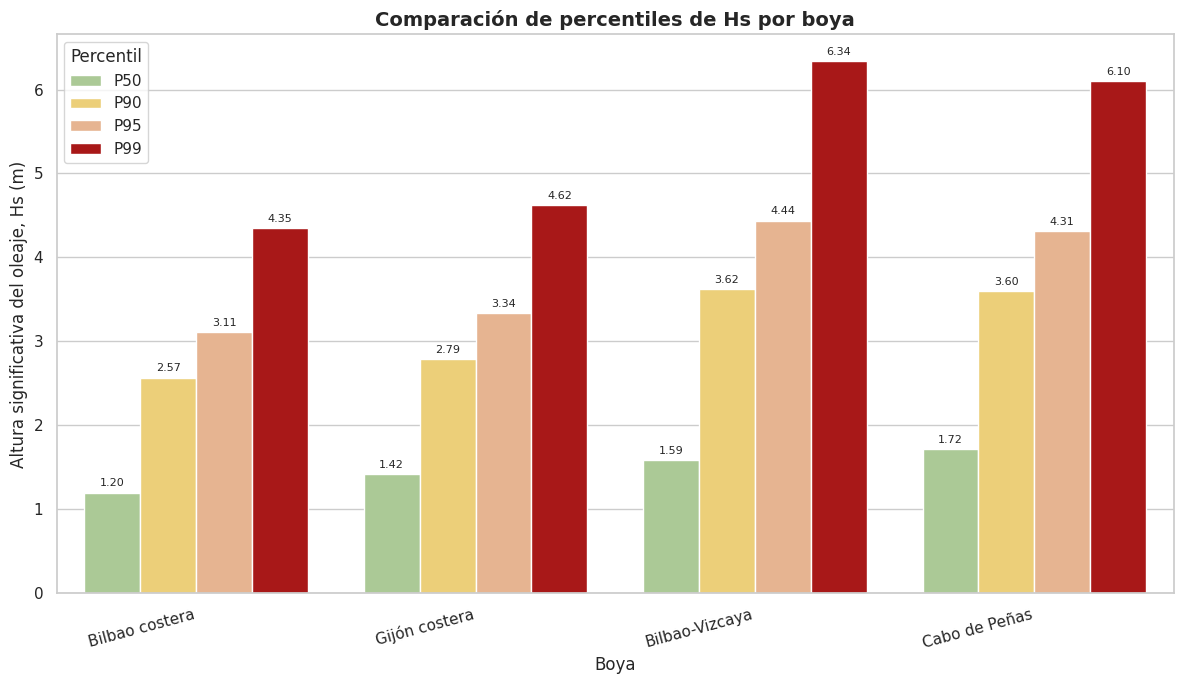

Figura guardada correctamente:
/content/figures/comparacion_percentiles_hs_por_boya.png


In [43]:
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=percentiles_largo,
    x="nombre_boya",
    y="Hs_m",
    hue="percentil",
    order=orden_boyas,
    hue_order=[
        "P50",
        "P90",
        "P95",
        "P99"
    ],
    palette=[
        "#A9D18E",
        "#FFD966",
        "#F4B183",
        "#C00000"
    ]
)

plt.title(
    "Comparación de percentiles de Hs por boya",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Boya")
plt.ylabel("Altura significativa del oleaje, Hs (m)")
plt.xticks(rotation=15, ha="right")

plt.legend(
    title="Percentil",
    loc="upper left"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=8
    )

plt.tight_layout()

ruta_figura_percentiles = (
    FIGURES_DIR / "comparacion_percentiles_hs_por_boya.png"
)

plt.savefig(
    ruta_figura_percentiles,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura guardada correctamente:")
print(ruta_figura_percentiles)

### Interpretación de los percentiles de Hs

La comparación de percentiles muestra una separación progresiva entre las condiciones habituales y los niveles de oleaje menos frecuentes.

El percentil 50 representa las condiciones centrales de cada serie. Los percentiles 90, 95 y 99 aumentan de forma considerable, especialmente en las boyas exteriores, lo que confirma la existencia de una distribución con una cola de valores elevados.

El percentil 95 constituye un indicador útil para caracterizar condiciones de oleaje alto, ya que representa un nivel superado únicamente por el 5 % de las observaciones. El percentil 99 permite aproximarse a situaciones todavía menos frecuentes sin depender de un único máximo absoluto.

Desde la perspectiva de la gestión portuaria, estos percentiles pueden emplearse como valores de referencia para caracterizar la exposición marítima, preparar el análisis de episodios potencialmente adversos y contextualizar la planificación de operaciones sensibles.

Los percentiles calculados no se interpretan como límites oficiales de operatividad o cierre portuario, sino como indicadores estadísticos obtenidos a partir de las series históricas.

COMPROBACIÓN FIGURAS Y TABLAS GENERADAS

In [44]:
print("FIGURAS DISPONIBLES")
print("-" * 50)

for archivo in sorted(os.listdir(FIGURES_DIR)):
    ruta = FIGURES_DIR / archivo
    tamano_kb = ruta.stat().st_size / 1024

    print(
        f"{archivo}: {tamano_kb:.2f} KB"
    )

FIGURAS DISPONIBLES
--------------------------------------------------
boxplot_hs_por_boya.png: 174.91 KB
cobertura_temporal_por_boya.png: 144.85 KB
comparacion_percentiles_hs_por_boya.png: 203.66 KB
distribucion_hs_por_tipo_boya.png: 88.76 KB
histogramas_hs_por_boya.png: 315.28 KB
numero_registros_por_boya.png: 206.15 KB


In [45]:
print("TABLAS DISPONIBLES")
print("-" * 50)

for archivo in sorted(os.listdir(TABLES_DIR)):
    ruta = TABLES_DIR / archivo
    tamano_kb = ruta.stat().st_size / 1024

    print(
        f"{archivo}: {tamano_kb:.2f} KB"
    )

TABLAS DISPONIBLES
--------------------------------------------------
tabla_distribucion_hs_por_tipo_boya.csv: 0.20 KB
tabla_estadisticos_hs_por_boya.csv: 0.50 KB
tabla_estadisticos_oleaje.csv: 0.53 KB
tabla_percentiles_hs_por_boya.csv: 0.24 KB
tabla_resumen_por_boya.csv: 0.58 KB
tabla_resumen_tipo_boya.csv: 0.28 KB


# SERIE TEMPORAL COMPLETA ALTURA DE OLA SIGNIFICANTE

## 4. Evolución temporal general de Hs

La representación de las series temporales permite observar la variabilidad de la altura significativa de ola a lo largo del periodo analizado.

Debido a que el dataset contiene más de 610.000 registros horarios, la representación directa de todas las observaciones produciría un gráfico excesivamente denso. Para mejorar su legibilidad, se calcula la media diaria y el máximo diario de Hs.

Esta agregación se utiliza únicamente para la representación gráfica. Los registros horarios originales se conservan íntegramente y serán utilizados en los análisis posteriores de estacionalidad, episodios adversos y predicción.

La media diaria muestra la evolución general del estado del mar, mientras que el máximo diario permite identificar visualmente los periodos

CREACIÓN DE SERIE DIARIA

In [46]:
serie_diaria_hs = (
    dataset_oleaje
    .set_index("fecha")
    .groupby(
        [
            "codigo_boya",
            "nombre_boya",
            "tipo_boya"
        ]
    )["Hs_m"]
    .resample("D")
    .agg(
        Hs_media_diaria_m="mean",
        Hs_maxima_diaria_m="max",
        observaciones_diarias="count"
    )
    .reset_index()
)

serie_diaria_hs[
    [
        "Hs_media_diaria_m",
        "Hs_maxima_diaria_m"
    ]
] = serie_diaria_hs[
    [
        "Hs_media_diaria_m",
        "Hs_maxima_diaria_m"
    ]
].round(2)

display(serie_diaria_hs.head())

,codigo_boya,nombre_boya,tipo_boya,fecha,Hs_media_diaria_m,Hs_maxima_diaria_m,observaciones_diarias
0,1103,Bilbao costera,Costera,2005-01-01,1.81,2.04,19
1,1103,Bilbao costera,Costera,2005-01-02,2.00,2.83,12
2,1103,Bilbao costera,Costera,2005-01-03,2.73,3.52,21
3,1103,Bilbao costera,Costera,2005-01-04,1.58,2.18,20
4,1103,Bilbao costera,Costera,2005-01-05,1.67,1.91,23


In [47]:
print("Número de registros diarios:", len(serie_diaria_hs))

print(
    "Fecha inicial:",
    serie_diaria_hs["fecha"].min()
)

print(
    "Fecha final:",
    serie_diaria_hs["fecha"].max()
)

print(
    "Boyas incluidas:",
    serie_diaria_hs["nombre_boya"].nunique()
)

Número de registros diarios: 29217
Fecha inicial: 2004-12-31 00:00:00
Fecha final: 2024-12-31 00:00:00
Boyas incluidas: 4


In [51]:
# Definir la ruta donde se guardará la serie diaria
ruta_serie_diaria = TABLES_DIR / "tabla_serie_diaria_hs.csv"

# Guardar la serie diaria en formato CSV
serie_diaria_hs.to_csv(
    ruta_serie_diaria,
    index=False,
    encoding="utf-8-sig"
)

# Comprobar que el archivo se ha guardado
print("Tabla guardada correctamente:")
print(ruta_serie_diaria)

print("¿Existe el archivo?", ruta_serie_diaria.exists())

tamano_mb = ruta_serie_diaria.stat().st_size / (1024 ** 2)

print(
    "Tamaño del archivo:",
    round(tamano_mb, 2),
    "MB"
)

Tabla guardada correctamente:
/content/tables/tabla_serie_diaria_hs.csv
¿Existe el archivo? True
Tamaño del archivo: 1.43 MB


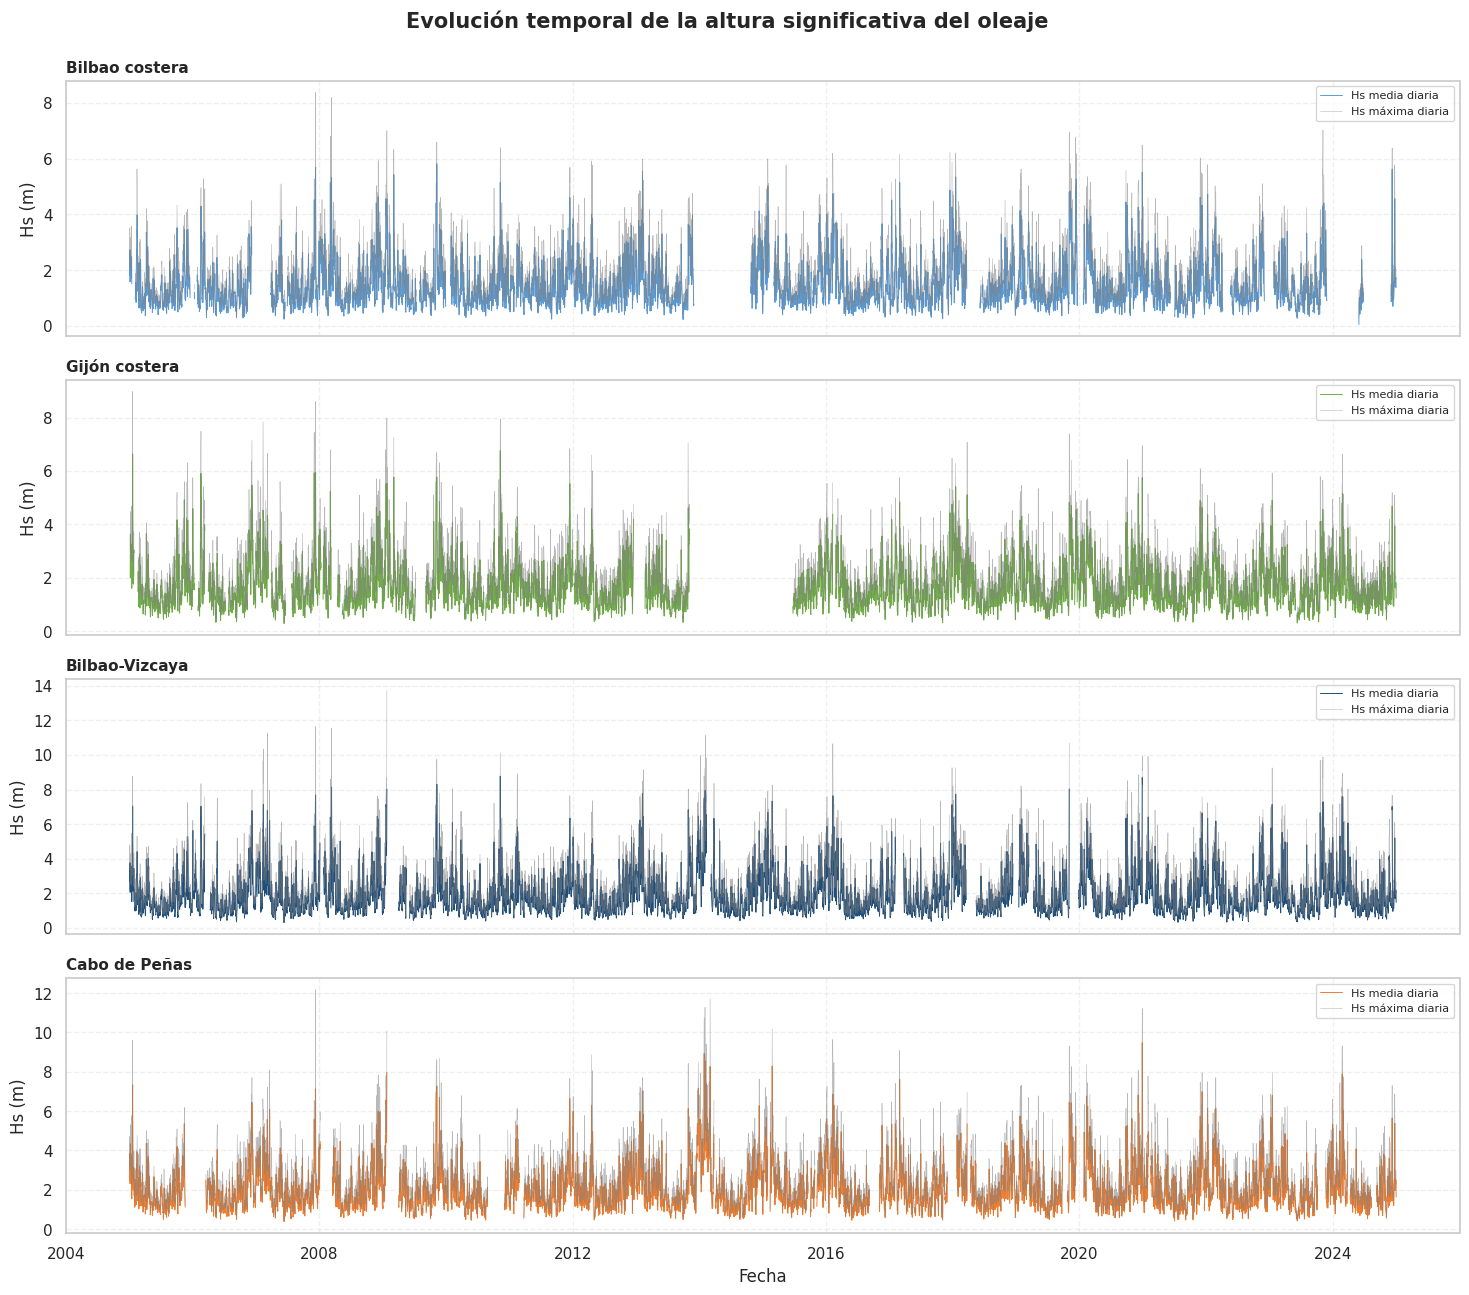

Figura guardada correctamente:
/content/figures/serie_temporal_hs_por_boya.png


In [52]:
# Colores asignados a cada boya
colores_boya = {
    "Bilbao costera": "#5B9BD5",
    "Gijón costera": "#70AD47",
    "Bilbao-Vizcaya": "#1F4E79",
    "Cabo de Peñas": "#ED7D31"
}

# Crear una figura con cuatro paneles
fig, axes = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(15, 13),
    sharex=True
)

# Dibujar una serie para cada boya
for ax, nombre_boya in zip(axes, orden_boyas):

    datos_boya = serie_diaria_hs[
        serie_diaria_hs["nombre_boya"] == nombre_boya
    ]

    # Hs media diaria
    ax.plot(
        datos_boya["fecha"],
        datos_boya["Hs_media_diaria_m"],
        color=colores_boya[nombre_boya],
        linewidth=0.7,
        label="Hs media diaria"
    )

    # Hs máxima diaria
    ax.plot(
        datos_boya["fecha"],
        datos_boya["Hs_maxima_diaria_m"],
        color="#7F7F7F",
        linewidth=0.4,
        alpha=0.55,
        label="Hs máxima diaria"
    )

    ax.set_title(
        nombre_boya,
        fontsize=11,
        fontweight="bold",
        loc="left"
    )

    ax.set_ylabel("Hs (m)")

    ax.grid(
        axis="both",
        linestyle="--",
        alpha=0.30
    )

    ax.legend(
        loc="upper right",
        fontsize=8
    )

# Etiqueta del eje horizontal
axes[-1].set_xlabel("Fecha")

# Título general
fig.suptitle(
    "Evolución temporal de la altura significativa del oleaje",
    fontsize=15,
    fontweight="bold",
    y=0.995
)

plt.tight_layout()

# Ruta de salida
ruta_serie_temporal = (
    FIGURES_DIR / "serie_temporal_hs_por_boya.png"
)

# Guardar la figura
plt.savefig(
    ruta_serie_temporal,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura guardada correctamente:")
print(ruta_serie_temporal)

### Interpretación de la evolución temporal

Las series temporales muestran una variabilidad elevada de Hs a lo largo del periodo de estudio. Se alternan intervalos con oleaje bajo o moderado y periodos de mayor intensidad, representados por picos en la media diaria y, especialmente, en el máximo diario.

Los episodios de mayor intensidad no aparecen distribuidos de forma uniforme a lo largo del tiempo, sino que se concentran en determinados periodos. Esta observación justifica el análisis temporal y estacional que se desarrollará en el siguiente notebook.

Las boyas exteriores presentan, de forma general, niveles diarios y episodios máximos superiores a los observados en las boyas costeras. Esta diferencia es coherente con el mayor grado de exposición de las estaciones exteriores a las condiciones de mar abierto.

La figura también permite observar posibles discontinuidades en las series. La presencia de intervalos sin representación puede corresponder a periodos sin observaciones válidas. Estos huecos deben tenerse en cuenta para evitar interpretar la ausencia de registros como ausencia de oleaje.

Desde la perspectiva de la gestión portuaria, la evolución temporal permite identificar periodos de mayor exposición y demuestra la utilidad de conservar series históricas extensas. Para obtener indicadores más fáciles de interpretar será necesario agrupar posteriormente la información por meses, estaciones, años y episodios.

# IDENTIFICACIÓN MÁXIMO DE HS PARA CADA BOYA

# Obtener el índice del mayor valor de Hs de cada boya
indices_maximos = (
    dataset_oleaje
    .groupby("codigo_boya")["Hs_m"]
    .idxmax()
)

# Seleccionar las variables asociadas al máximo
tabla_maximos_hs = (
    dataset_oleaje
    .loc[
        indices_maximos,
        [
            "codigo_boya",
            "nombre_boya",
            "tipo_boya",
            "fecha",
            "Hs_m",
            "Hmax_m",
            "Tm02_s",
            "Tp_s",
            "dir_media_oleaje_grados",
            "dir_pico_oleaje_grados"
        ]
    ]
    .sort_values("codigo_boya")
    .reset_index(drop=True)
)

display(tabla_maximos_hs)

In [53]:
# Obtener el índice del mayor valor de Hs de cada boya
indices_maximos = (
    dataset_oleaje
    .groupby("codigo_boya")["Hs_m"]
    .idxmax()
)

# Seleccionar las variables asociadas al máximo
tabla_maximos_hs = (
    dataset_oleaje
    .loc[
        indices_maximos,
        [
            "codigo_boya",
            "nombre_boya",
            "tipo_boya",
            "fecha",
            "Hs_m",
            "Hmax_m",
            "Tm02_s",
            "Tp_s",
            "dir_media_oleaje_grados",
            "dir_pico_oleaje_grados"
        ]
    ]
    .sort_values("codigo_boya")
    .reset_index(drop=True)
)

display(tabla_maximos_hs)

,codigo_boya,nombre_boya,tipo_boya,fecha,Hs_m,Hmax_m,Tm02_s,Tp_s,dir_media_oleaje_grados,dir_pico_oleaje_grados
0,1103,Bilbao costera,Costera,2007-12-10 02:00:00,8.37,13.72,10.45,14.26,338.00,341.00
1,1117,Gijón costera,Costera,2005-01-19 02:00:00,8.98,13.53,11.57,16.64,342.00,348.00
2,2136,Bilbao-Vizcaya,Exterior,2009-01-24 08:00:00,13.72,20.78,11.44,14.28,292.00,290.00
3,2242,Cabo de Peñas,Exterior,2007-12-09 21:00:00,12.18,23.28,11.86,16.66,315.00,319.00


In [54]:
ruta_tabla_maximos = (
    TABLES_DIR / "tabla_maximos_hs_por_boya.csv"
)

tabla_maximos_hs.to_csv(
    ruta_tabla_maximos,
    index=False,
    encoding="utf-8-sig"
)

print("Tabla guardada correctamente:")
print(ruta_tabla_maximos)

Tabla guardada correctamente:
/content/tables/tabla_maximos_hs_por_boya.csv


### Observaciones máximas de Hs

La identificación de los máximos permite localizar los registros de mayor altura significativa de ola en cada serie. Sin embargo, estos valores deben interpretarse con cautela, ya que corresponden a observaciones puntuales y no describen por sí solos el comportamiento habitual de cada estación.

Los máximos son útiles para seleccionar eventos concretos que requieran una revisión posterior, pero no deben utilizarse de forma aislada para establecer conclusiones sobre operatividad portuaria.

Por este motivo, el análisis exploratorio combina máximos, medianas y percentiles. Los percentiles proporcionan niveles estadísticos más estables, mientras que los máximos permiten identificar episodios concretos para su estudio detallado.

Los valores máximos registrados por las boyas exteriores son superiores a los observados en las estaciones costeras, en coherencia con la mayor exposición de las primeras a las condiciones de mar abierto.

RESUMEN NOTEBOOK 02_ANÁLISIS EXPLORATORIO

In [55]:
print("RESUMEN DEL ANÁLISIS EXPLORATORIO")
print("=" * 60)

print(
    "Registros analizados:",
    f"{len(dataset_oleaje):,}"
)

print(
    "Número de boyas:",
    dataset_oleaje["codigo_boya"].nunique()
)

print(
    "Periodo global:",
    dataset_oleaje["fecha"].min(),
    "-",
    dataset_oleaje["fecha"].max()
)

print("\nHs media por boya:")

for _, fila in tabla_estadisticos_oleaje.iterrows():
    print(
        "-",
        fila["nombre_boya"],
        ":",
        fila["Hs_media_m"],
        "m"
    )

print("\nPercentil 95 de Hs por boya:")

for _, fila in percentiles_hs.iterrows():
    print(
        "-",
        fila["nombre_boya"],
        ":",
        fila["P95"],
        "m"
    )

print("\nMáximo de Hs por boya:")

for _, fila in tabla_maximos_hs.iterrows():
    print(
        "-",
        fila["nombre_boya"],
        ":",
        fila["Hs_m"],
        "m -",
        fila["fecha"]
    )

RESUMEN DEL ANÁLISIS EXPLORATORIO
Registros analizados: 610,438
Número de boyas: 4
Periodo global: 2004-12-31 00:00:00 - 2024-12-31 23:00:00

Hs media por boya:
- Bilbao costera : 1.43 m
- Gijón costera : 1.63 m
- Bilbao-Vizcaya : 1.94 m
- Cabo de Peñas : 2.03 m

Percentil 95 de Hs por boya:
- Bilbao costera : 3.11 m
- Gijón costera : 3.34 m
- Bilbao-Vizcaya : 4.44 m
- Cabo de Peñas : 4.31 m

Máximo de Hs por boya:
- Bilbao costera : 8.37 m - 2007-12-10 02:00:00
- Gijón costera : 8.98 m - 2005-01-19 02:00:00
- Bilbao-Vizcaya : 13.72 m - 2009-01-24 08:00:00
- Cabo de Peñas : 12.18 m - 2007-12-09 21:00:00


## 5. Conclusiones del análisis exploratorio

El análisis exploratorio ha permitido comprobar que el dataset principal de oleaje contiene un volumen elevado de información y una cobertura temporal suficiente para desarrollar los análisis posteriores.

Las cuatro boyas aportan series que abarcan aproximadamente veinte años. La distribución de los registros es relativamente equilibrada, aunque existen diferencias asociadas a la disponibilidad histórica de cada estación.

La altura significativa de ola presenta una distribución asimétrica hacia valores elevados. La mayor parte de las observaciones corresponde a condiciones bajas o moderadas, mientras que los episodios de mayor intensidad aparecen con menor frecuencia y generan una cola derecha prolongada.

Las boyas exteriores presentan valores centrales, percentiles altos y máximos superiores a los observados en las boyas costeras. Este resultado es coherente con la mayor exposición de las estaciones exteriores a las condiciones de mar abierto. Las diferencias no deben interpretarse como una clasificación entre puertos, sino como consecuencia del contexto de medición.

Los percentiles 90, 95 y 99 se consideran indicadores adecuados para caracterizar niveles de oleaje elevado. Frente a los máximos absolutos, los percentiles presentan mayor estabilidad y permiten describir condiciones poco frecuentes a partir del conjunto de la serie.

La representación temporal confirma la existencia de una variabilidad importante y de episodios puntuales con Hs elevada. También muestra la necesidad de estudiar la distribución temporal de los registros mediante indicadores mensuales, estacionales y anuales.

Desde la perspectiva de la gestión portuaria, el análisis exploratorio convierte las series de boyas en información objetiva sobre condiciones habituales, variabilidad y niveles altos de oleaje. Esta información constituye la base para desarrollar indicadores de exposición, detectar episodios potencialmente adversos y construir posteriormente modelos exploratorios de predicción.

El siguiente notebook se centrará en los indicadores temporales y estacionales del oleaje.

Comprobación de las tablas y figuras generadas para los anexos

In [56]:
print("TABLAS GENERADAS EN EL NOTEBOOK 02")
print("-" * 60)

for archivo in sorted(os.listdir(TABLES_DIR)):
    ruta = TABLES_DIR / archivo
    tamano_kb = ruta.stat().st_size / 1024

    print(
        archivo,
        "-",
        round(tamano_kb, 2),
        "KB"
    )

TABLAS GENERADAS EN EL NOTEBOOK 02
------------------------------------------------------------
tabla_distribucion_hs_por_tipo_boya.csv - 0.2 KB
tabla_estadisticos_hs_por_boya.csv - 0.5 KB
tabla_estadisticos_oleaje.csv - 0.53 KB
tabla_maximos_hs_por_boya.csv - 0.44 KB
tabla_percentiles_hs_por_boya.csv - 0.24 KB
tabla_resumen_por_boya.csv - 0.58 KB
tabla_resumen_tipo_boya.csv - 0.28 KB
tabla_serie_diaria_hs.csv - 1463.34 KB


In [57]:
print("FIGURAS GENERADAS EN EL NOTEBOOK 02")
print("-" * 60)

for archivo in sorted(os.listdir(FIGURES_DIR)):
    ruta = FIGURES_DIR / archivo
    tamano_kb = ruta.stat().st_size / 1024

    print(
        archivo,
        "-",
        round(tamano_kb, 2),
        "KB"
    )

FIGURAS GENERADAS EN EL NOTEBOOK 02
------------------------------------------------------------
boxplot_hs_por_boya.png - 174.91 KB
cobertura_temporal_por_boya.png - 144.85 KB
comparacion_percentiles_hs_por_boya.png - 203.66 KB
distribucion_hs_por_tipo_boya.png - 88.76 KB
histogramas_hs_por_boya.png - 315.28 KB
numero_registros_por_boya.png - 206.15 KB
serie_temporal_hs_por_boya.png - 2127.9 KB


In [58]:
import shutil

shutil.make_archive(
    "/content/figuras_notebook_02",
    "zip",
    FIGURES_DIR
)

shutil.make_archive(
    "/content/tablas_notebook_02",
    "zip",
    TABLES_DIR
)

print("Archivos ZIP creados correctamente:")
print("/content/figuras_notebook_02.zip")
print("/content/tablas_notebook_02.zip")

Archivos ZIP creados correctamente:
/content/figuras_notebook_02.zip
/content/tablas_notebook_02.zip


In [59]:
from pathlib import Path

ruta_zip_figuras = Path(
    "/content/figuras_notebook_02.zip"
)

ruta_zip_tablas = Path(
    "/content/tablas_notebook_02.zip"
)

print(
    "ZIP de figuras:",
    ruta_zip_figuras.exists()
)

print(
    "ZIP de tablas:",
    ruta_zip_tablas.exists()
)

ZIP de figuras: True
ZIP de tablas: True


In [60]:
from google.colab import files

files.download(
    "/content/figuras_notebook_02.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [61]:
files.download(
    "/content/tablas_notebook_02.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>